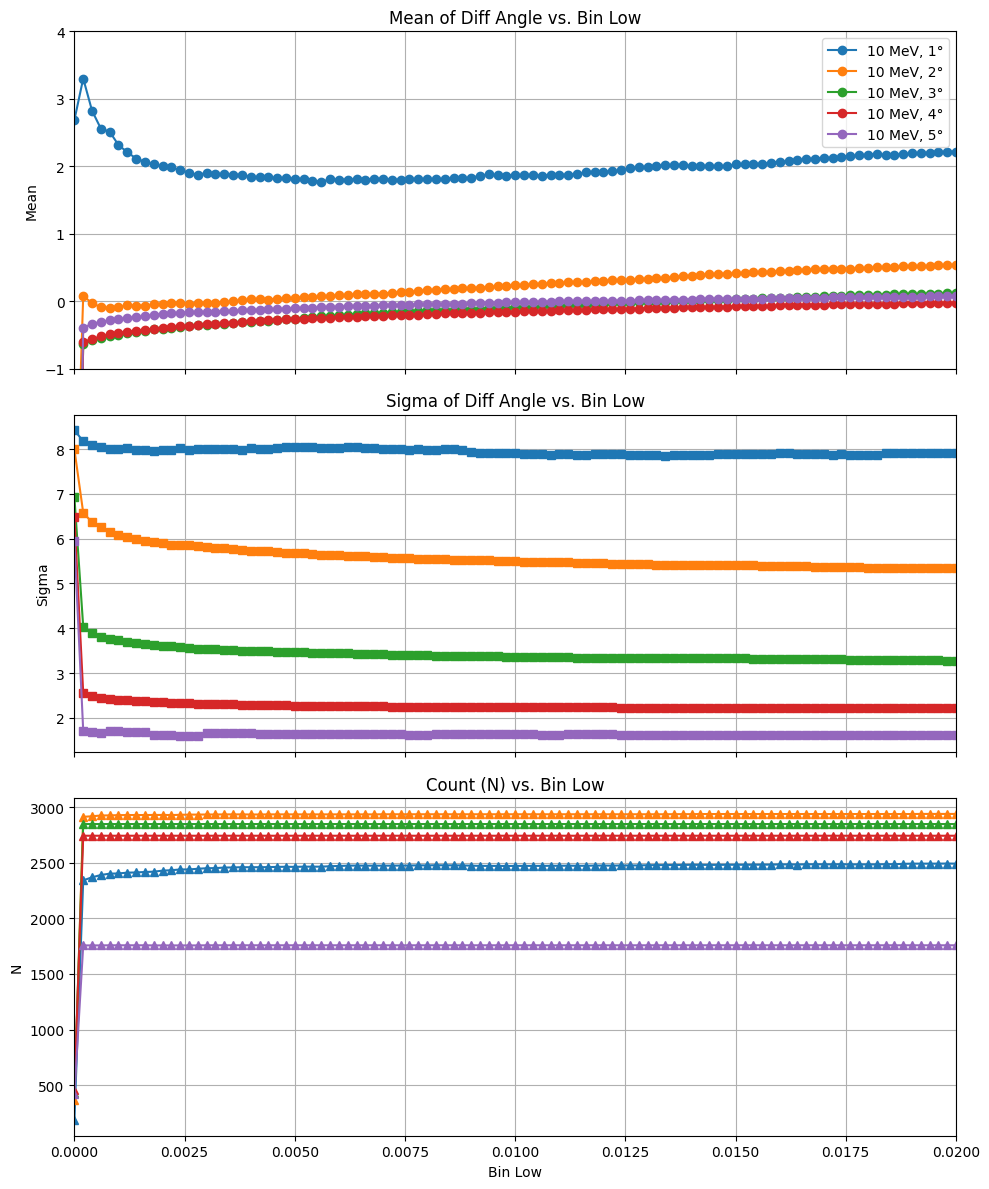

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the array
data = np.load("angle_diff_resp.npy")

# Each row: [energy, cm, bin_low, bin_high, len_diffs, mean, sigma]
energies = data[:, 0]
cms = data[:, 1]
bin_lows = data[:, 2]
len_diffs = data[:, 4]
means = data[:, 5]
sigmas = data[:, 6]

# Find all unique (energy, cm) combinations
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot for each unique (energy, cm)
for energy, cm in unique_combinations:
    # Mask for current (energy, cm)
    mask = (data[:, 0] == energy) & (data[:, 1] == cm)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    sigma_vals = data[mask][:, 6]
    len_vals = data[mask][:, 4]

    label = f"{int(energy)} MeV, {int(cm)}°"
    
    # Plot Mean vs. bin_low
    ax1.plot(bin_low_vals, mean_vals, marker='o', label=label)
    
    # Plot Sigma vs. bin_low
    ax2.plot(bin_low_vals, sigma_vals, marker='s', label=label)
    
    # Plot Len vs. bin_low
    ax3.plot(bin_low_vals, len_vals, marker='^', label=label)

# Mean subplot
ax1.set_title("Mean of Diff Angle vs. Bin Low")
ax1.set_ylabel("Mean")
ax1.set_xlim([0,0.02])
ax1.set_ylim([-1,4])
ax1.legend()
ax1.grid(True)

# Sigma subplot
ax2.set_title("Sigma of Diff Angle vs. Bin Low")
ax2.set_ylabel("Sigma")
ax2.grid(True)

# Length subplot
ax3.set_title("Count (N) vs. Bin Low")
ax3.set_ylabel("N")
ax3.set_xlabel("Bin Low")
ax3.grid(True)

plt.tight_layout()
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_20436\2810837319.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))


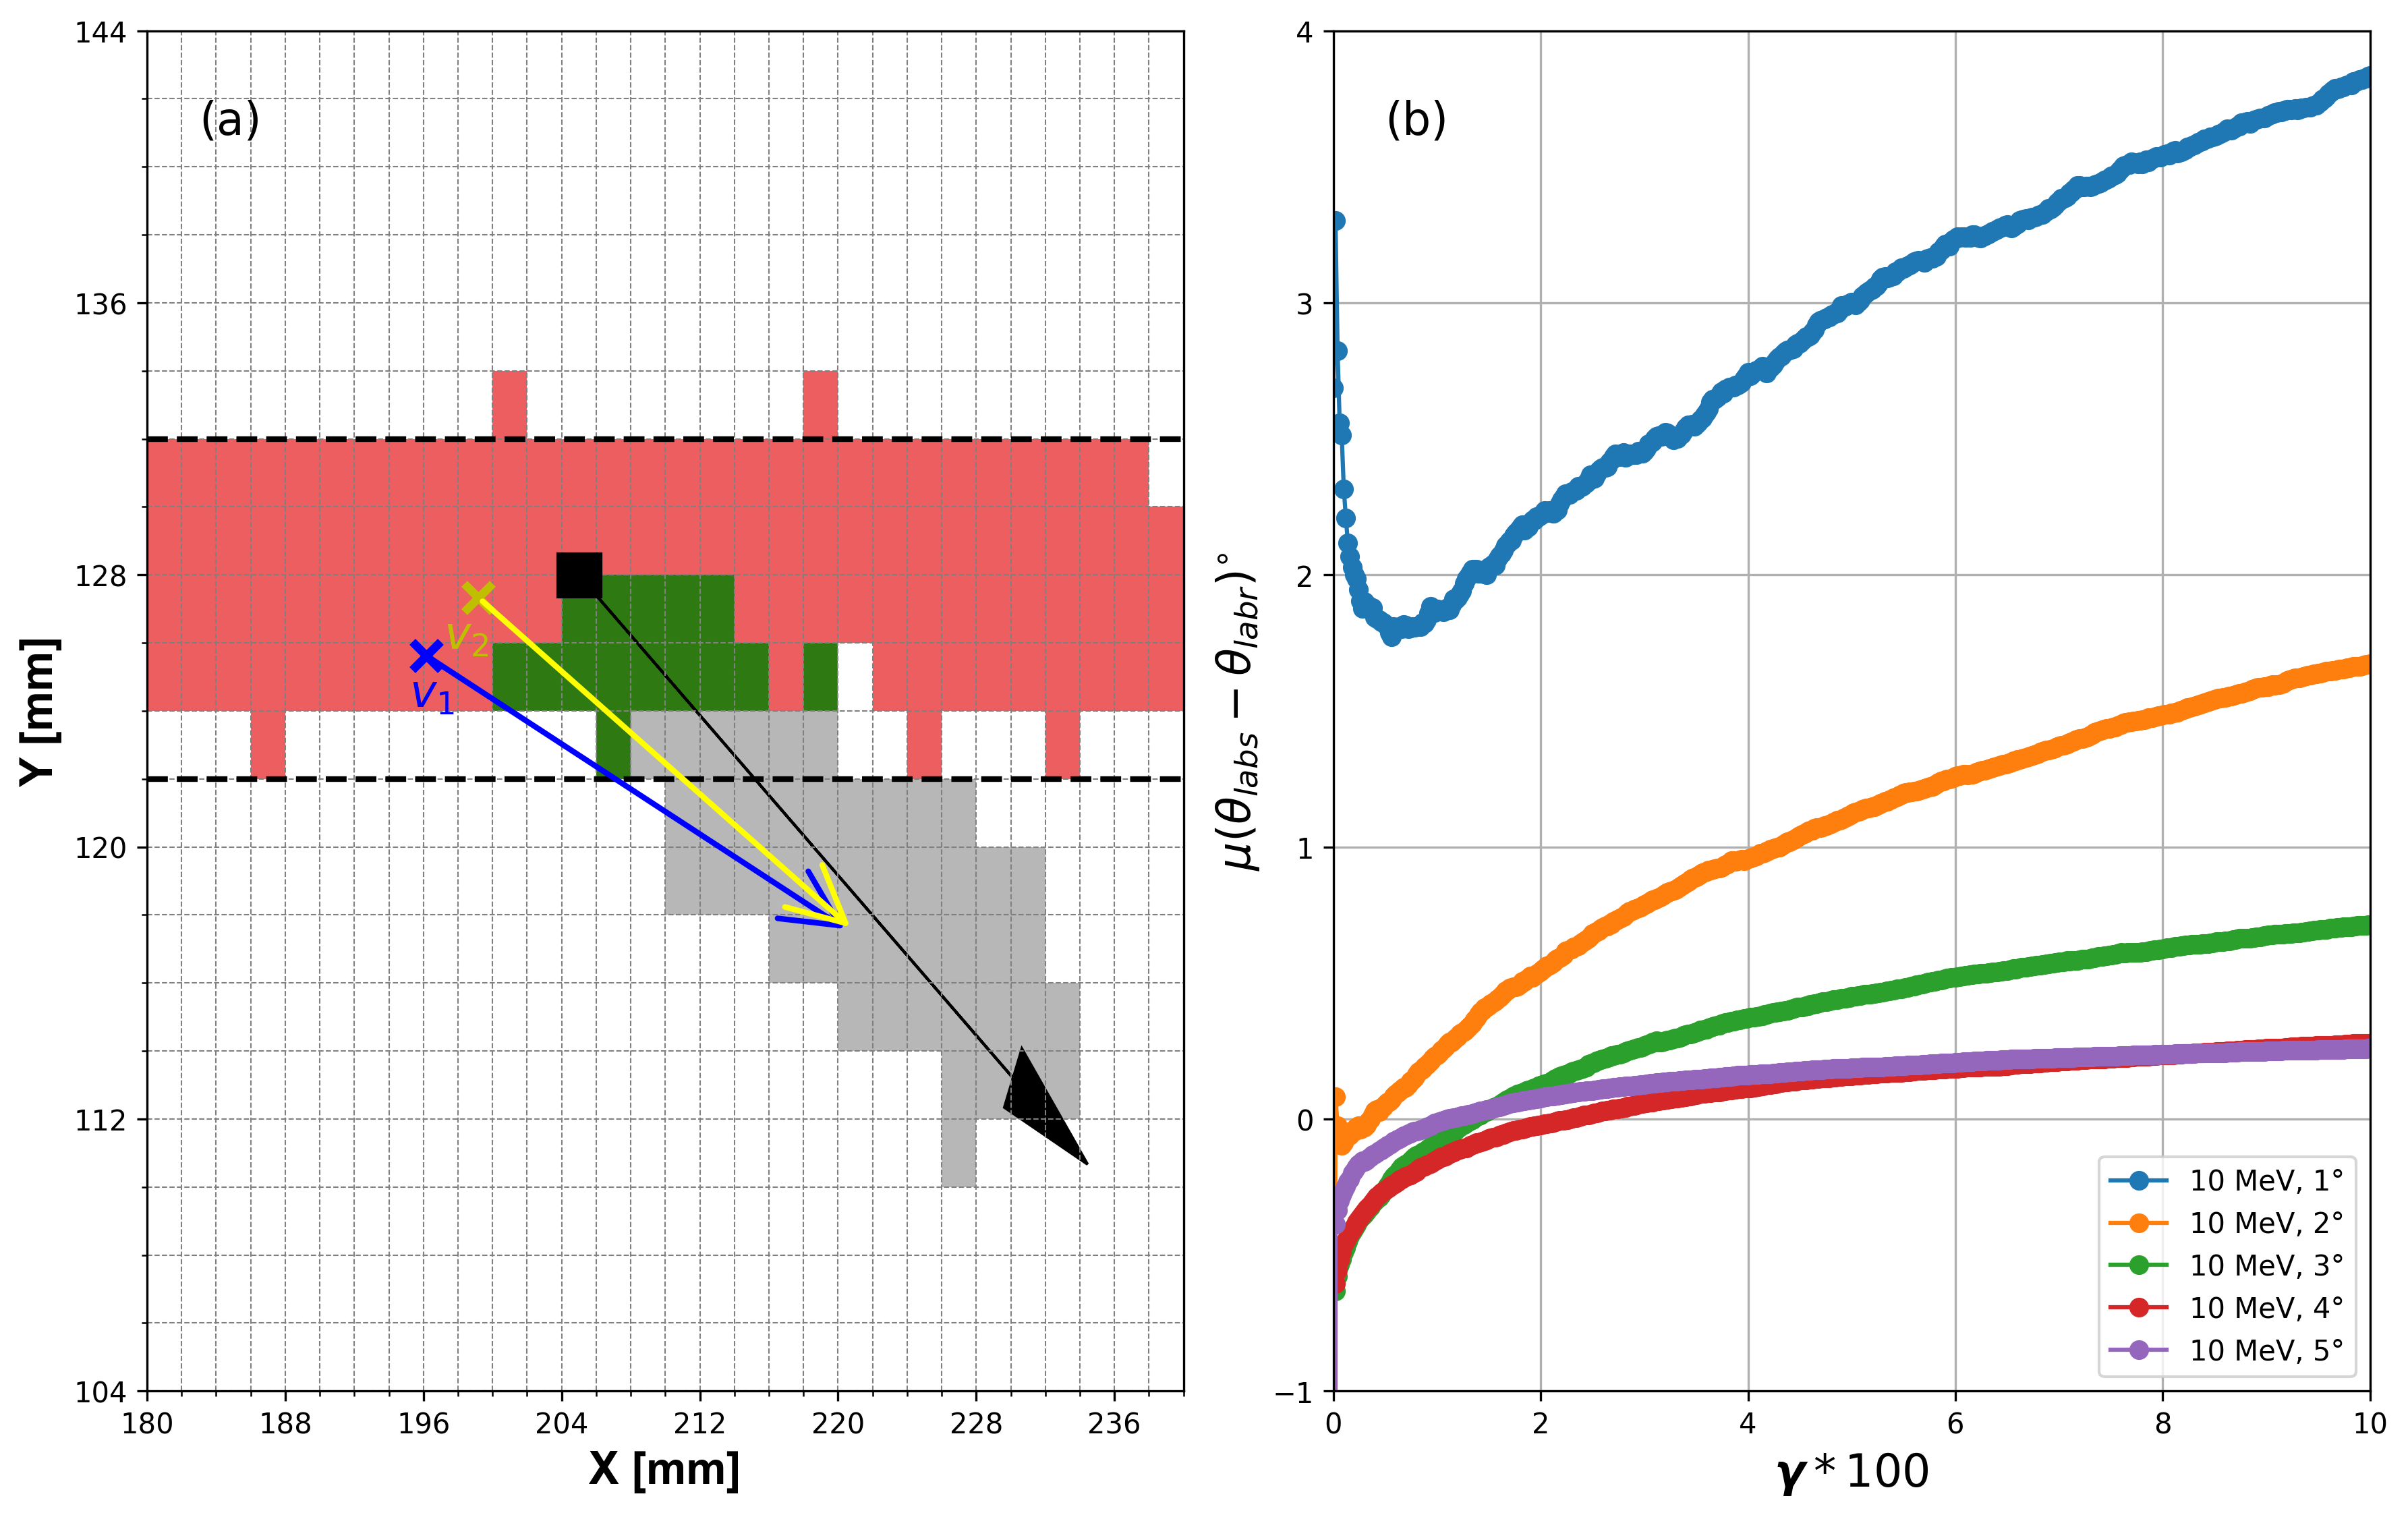

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

# Load the saved clusters from the specified iterations
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]

xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

# Set plot limits and grid size
x_limits = (180, 240)
y_limits = (104, 144)
pixel_size_mm = 2

# Create a 2x2 subplot for double-column format
fig, axs = plt.subplots(1, 2, figsize=(12, 8), dpi=300)

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}

# Function to add rectangle patches for each point
def add_rectangles(ax, xyz_data, labels, cmap):
    for (x, y, _), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm, linewidth=0.5,
                                 edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid and sparse Y-axis tick labels
def set_custom_grid(ax):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Set grid ticks every 2 mm on both axes
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=False)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, 8), minor=False)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, 8), minor=False)
    
    # Display grid
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

    # Label Y-axis major ticks every 8 mm
    y_labels = np.arange(y_limits[0], y_limits[1] + 1, 8)
    ax.set_yticklabels(y_labels)

    # Add thicker grid lines between Y = 122 and Y = 132
    ax.axhline(y=122, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=122
    ax.axhline(y=132, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=132


cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))
# Plot Initial Clusters
set_custom_grid(axs[0])
add_rectangles(axs[0], xyz_initial, labels_initial, cmap)
axs[0].set_xlabel('X [mm]', fontname='Arial', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Y [mm]', fontname='Arial', fontsize=16, fontweight='bold')

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]


# Add rectangles for mask_clusters in a different color (e.g., red)
for (x, y, _) in mask_clusters:
    rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                             linewidth=0.5, edgecolor='none', facecolor='green', alpha=0.8)
    axs[0].add_patch(rect)


mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, 0.16])

# Set a scaling factor to determine the length of the arrow (you can adjust this value)
scaling_factor = 29.56  # This controls how long the direction vector is on the plot

# Plot the mean point (starting point) and direction vector using ax.arrow
axs[0].arrow(mean_vector_1[0], mean_vector_1[1], direction_vector_1[0] * scaling_factor, direction_vector_1[1] * scaling_factor, 
          head_width=2, head_length=5, fc='k', ec='k')

axs[0].plot(mean_vector_1[0], mean_vector_1[1],
            marker='s', color='k', markersize=15,
            markeredgecolor='k', markeredgewidth=1.5,
            label='Mean Vector')


axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, fontsize=16, verticalalignment='top')


end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062]) 
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
# end_point_3 = np.array([180.69, 139.2822, 112.8984])
# start_point_3 = np.array([119.1046, 128.7794, 128.5239])

# axs[0].plot(end_point_1[0], end_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_1[0] + 1, end_point_1[1], '$e_1$', color='b', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_1[0], start_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_1[0] - 1, start_point_1[1] - 1.5, '$v_1$', color='b', fontsize=16, fontweight='bold') 

# axs[0].plot(end_point_2[0], end_point_2[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_2[0] + 1, end_point_2[1] - 2, '$e_2$', color='g', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_2[0], start_point_2[1], 'yx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_2[0]-2, start_point_2[1] - 1.5, '$v_2$', color='y', fontsize=16, fontweight='bold') 

# axs[0].plot(start_point_3[0], start_point_3[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(start_point_3[0]-2, start_point_3[1] - 1.5, '$v_2$', color='g', fontsize=16, fontweight='bold') 

# Scaling factor (how much to extend)
# scaling_factor = 1.0  # for example

# # Calculate directions
# dir1 = end_point_1 - start_point_1
# dir2 = end_point_2 - start_point_2

# # Extend points
# new_start_point_1 = start_point_1 
# new_end_point_1 = end_point_1 + scaling_factor * dir1

# new_start_point_2 = start_point_2 
# new_end_point_2 = end_point_2 + scaling_factor * dir2

# # Line 1 (XY projection)
# axs[0].plot(
#     [start_point_1[0], end_point_1[0]],
#     [start_point_1[1], end_point_1[1]],
#     color='blue',
#     linestyle='-',
#     linewidth=2,
#     label='Track 1 Extended'
# )

# # Line 2 (XY projection)
# axs[0].plot(
#     [start_point_2[0], end_point_2[0]],
#     [start_point_2[1], end_point_2[1]],
#     color='yellow',
#     linestyle='-',
#     linewidth=2,
#     label='Track 2 Extended'
# )

# Arrow 1 (Track 1 Extended)
axs[0].annotate(
    '', 
    xy=end_point_1[:2],
    xytext=start_point_1[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='blue',
        linewidth=2
    )
)

axs[0].annotate(
    '', 
    xy=end_point_2[:2],
    xytext=start_point_2[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='yellow',
        linewidth=2
    )
)

# Load the array
data = np.load("angle_diff_resp.npy")

# Each row: [energy, cm, bin_low, bin_high, len_diffs, mean, sigma]
energies = data[:, 0]
cms = data[:, 1]
bin_lows = data[:, 2]
len_diffs = data[:, 4]
means = data[:, 5]
sigmas = data[:, 6]

# Find all unique (energy, cm) combinations
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

# Plot for each unique (energy, cm)
for energy, cm in unique_combinations:
    # Mask for current (energy, cm)
    mask = (data[:, 0] == energy) & (data[:, 1] == cm)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    sigma_vals = data[mask][:, 6]
    len_vals = data[mask][:, 4]

    label = f"{int(energy)} MeV, {int(cm)}°"
    
    # Plot Mean vs. bin_low
    axs[1].plot(bin_low_vals*100, mean_vals, marker='o', label=label)
     
# Mean subplot
axs[1].set_xlabel(r'$\boldsymbol{\gamma} * 100$', fontsize=16, fontweight='bold')
axs[1].set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
axs[1].text(0.05, 0.95, '(b)', transform=axs[1].transAxes, fontsize=16, verticalalignment='top')
axs[1].set_xlim([0*100,0.1*100])
axs[1].set_ylim([-1,4])
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('gamma.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_20436\3128609982.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))


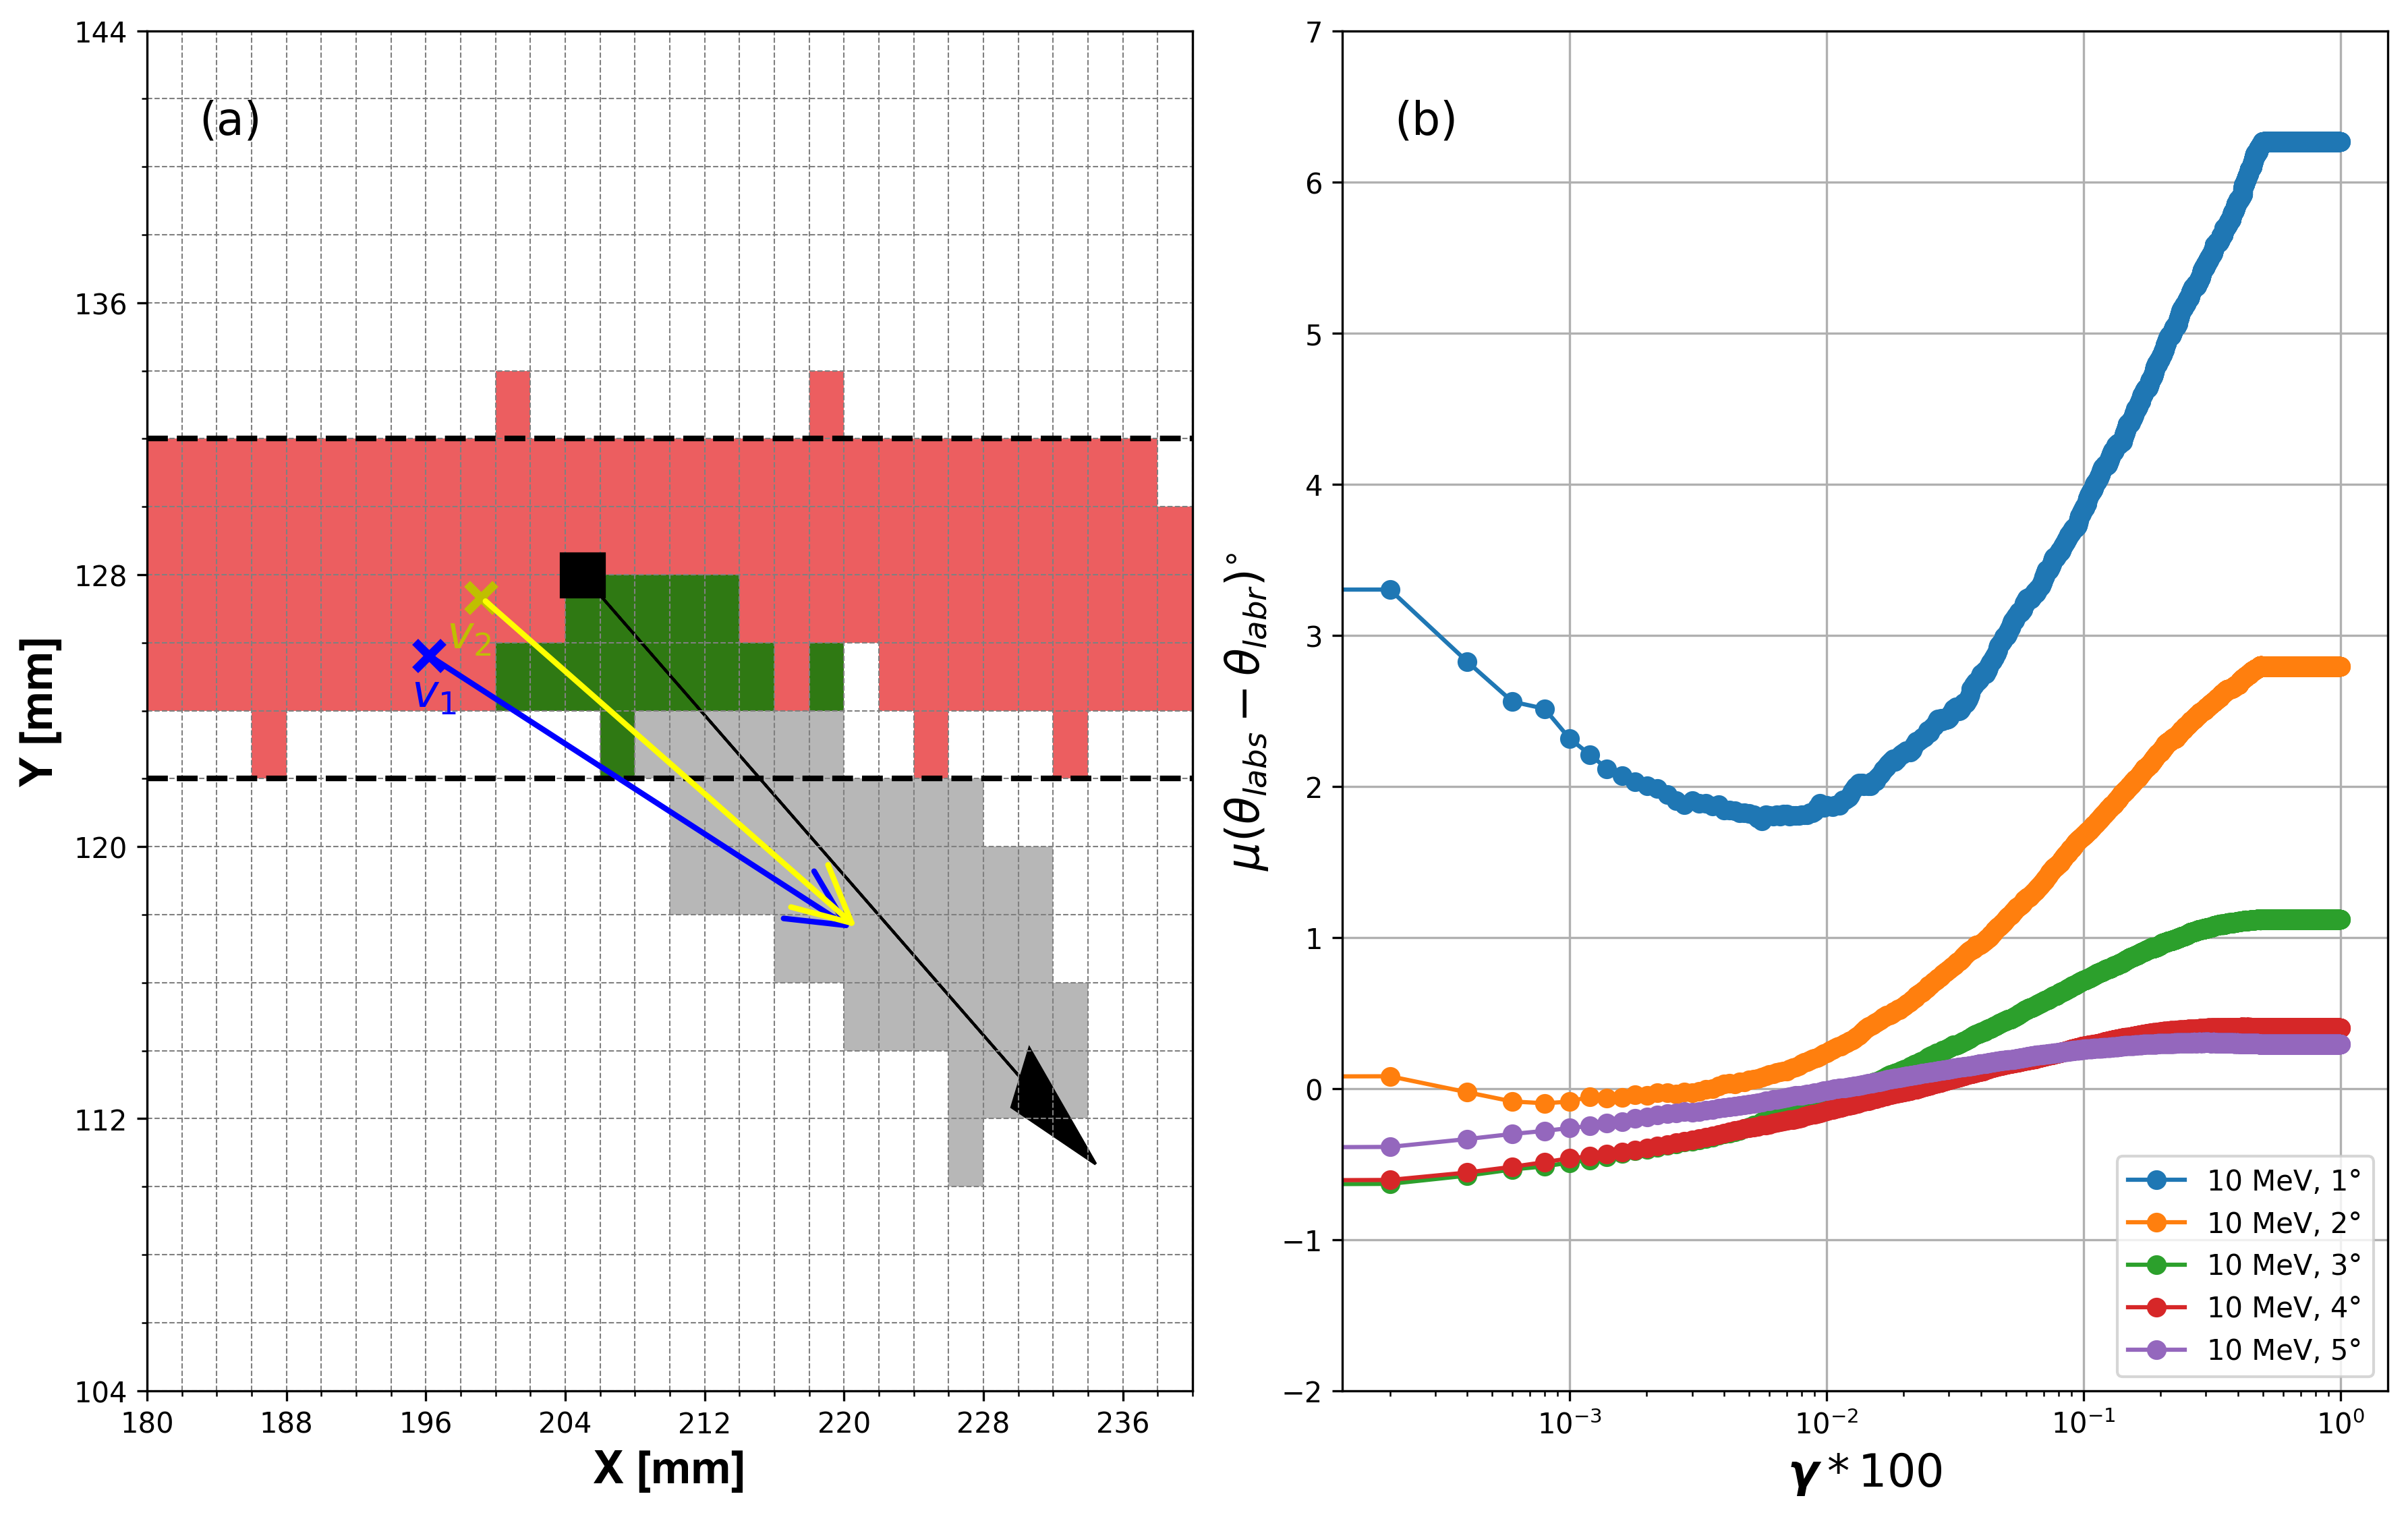

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

# Load the saved clusters from the specified iterations
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]

xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

# Set plot limits and grid size
x_limits = (180, 240)
y_limits = (104, 144)
pixel_size_mm = 2

# Create a 2x2 subplot for double-column format
fig, axs = plt.subplots(1, 2, figsize=(12, 8), dpi=300)

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}

# Function to add rectangle patches for each point
def add_rectangles(ax, xyz_data, labels, cmap):
    for (x, y, _), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm, linewidth=0.5,
                                 edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid and sparse Y-axis tick labels
def set_custom_grid(ax):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Set grid ticks every 2 mm on both axes
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=False)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, 8), minor=False)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, 8), minor=False)
    
    # Display grid
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

    # Label Y-axis major ticks every 8 mm
    y_labels = np.arange(y_limits[0], y_limits[1] + 1, 8)
    ax.set_yticklabels(y_labels)

    # Add thicker grid lines between Y = 122 and Y = 132
    ax.axhline(y=122, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=122
    ax.axhline(y=132, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=132


cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))
# Plot Initial Clusters
set_custom_grid(axs[0])
add_rectangles(axs[0], xyz_initial, labels_initial, cmap)
axs[0].set_xlabel('X [mm]', fontname='Arial', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Y [mm]', fontname='Arial', fontsize=16, fontweight='bold')

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]


# Add rectangles for mask_clusters in a different color (e.g., red)
for (x, y, _) in mask_clusters:
    rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                             linewidth=0.5, edgecolor='none', facecolor='green', alpha=0.8)
    axs[0].add_patch(rect)


mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, 0.16])

# Set a scaling factor to determine the length of the arrow (you can adjust this value)
scaling_factor = 29.56  # This controls how long the direction vector is on the plot

# Plot the mean point (starting point) and direction vector using ax.arrow
axs[0].arrow(mean_vector_1[0], mean_vector_1[1], direction_vector_1[0] * scaling_factor, direction_vector_1[1] * scaling_factor, 
          head_width=2, head_length=5, fc='k', ec='k')

axs[0].plot(mean_vector_1[0], mean_vector_1[1],
            marker='s', color='k', markersize=15,
            markeredgecolor='k', markeredgewidth=1.5,
            label='Mean Vector')


axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, fontsize=16, verticalalignment='top')


end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062]) 
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
# end_point_3 = np.array([180.69, 139.2822, 112.8984])
# start_point_3 = np.array([119.1046, 128.7794, 128.5239])

# axs[0].plot(end_point_1[0], end_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_1[0] + 1, end_point_1[1], '$e_1$', color='b', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_1[0], start_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_1[0] - 1, start_point_1[1] - 1.5, '$v_1$', color='b', fontsize=16, fontweight='bold') 

# axs[0].plot(end_point_2[0], end_point_2[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_2[0] + 1, end_point_2[1] - 2, '$e_2$', color='g', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_2[0], start_point_2[1], 'yx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_2[0]-2, start_point_2[1] - 1.5, '$v_2$', color='y', fontsize=16, fontweight='bold') 

# axs[0].plot(start_point_3[0], start_point_3[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(start_point_3[0]-2, start_point_3[1] - 1.5, '$v_2$', color='g', fontsize=16, fontweight='bold') 

# Scaling factor (how much to extend)
# scaling_factor = 1.0  # for example

# # Calculate directions
# dir1 = end_point_1 - start_point_1
# dir2 = end_point_2 - start_point_2

# # Extend points
# new_start_point_1 = start_point_1 
# new_end_point_1 = end_point_1 + scaling_factor * dir1

# new_start_point_2 = start_point_2 
# new_end_point_2 = end_point_2 + scaling_factor * dir2

# # Line 1 (XY projection)
# axs[0].plot(
#     [start_point_1[0], end_point_1[0]],
#     [start_point_1[1], end_point_1[1]],
#     color='blue',
#     linestyle='-',
#     linewidth=2,
#     label='Track 1 Extended'
# )

# # Line 2 (XY projection)
# axs[0].plot(
#     [start_point_2[0], end_point_2[0]],
#     [start_point_2[1], end_point_2[1]],
#     color='yellow',
#     linestyle='-',
#     linewidth=2,
#     label='Track 2 Extended'
# )

# Arrow 1 (Track 1 Extended)
axs[0].annotate(
    '', 
    xy=end_point_1[:2],
    xytext=start_point_1[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='blue',
        linewidth=2
    )
)

axs[0].annotate(
    '', 
    xy=end_point_2[:2],
    xytext=start_point_2[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='yellow',
        linewidth=2
    )
)

# Load the array
data = np.load("angle_diff_resp.npy")

# Each row: [energy, cm, bin_low, bin_high, len_diffs, mean, sigma]
energies = data[:, 0]
cms = data[:, 1]
bin_lows = data[:, 2]
len_diffs = data[:, 4]
means = data[:, 5]
sigmas = data[:, 6]

# Find all unique (energy, cm) combinations
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

# Plot for each unique (energy, cm)
for energy, cm in unique_combinations:
    # Mask for current (energy, cm)
    mask = (data[:, 0] == energy) & (data[:, 1] == cm)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    sigma_vals = data[mask][:, 6]
    len_vals = data[mask][:, 4]

    label = f"{int(energy)} MeV, {int(cm)}°"
    
    # Plot Mean vs. bin_low
    axs[1].plot(bin_low_vals, mean_vals, marker='o', label=label)
     
# Mean subplot
axs[1].set_xscale('log')
axs[1].set_xlabel(r'$\boldsymbol{\gamma} * 100$', fontsize=16, fontweight='bold')
axs[1].set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
axs[1].text(0.05, 0.95, '(b)', transform=axs[1].transAxes, fontsize=16, verticalalignment='top')
# axs[1].set_xlim([0*100,0.1*100])
axs[1].set_ylim([-2,7])
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('gamma.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_20436\1974761627.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))


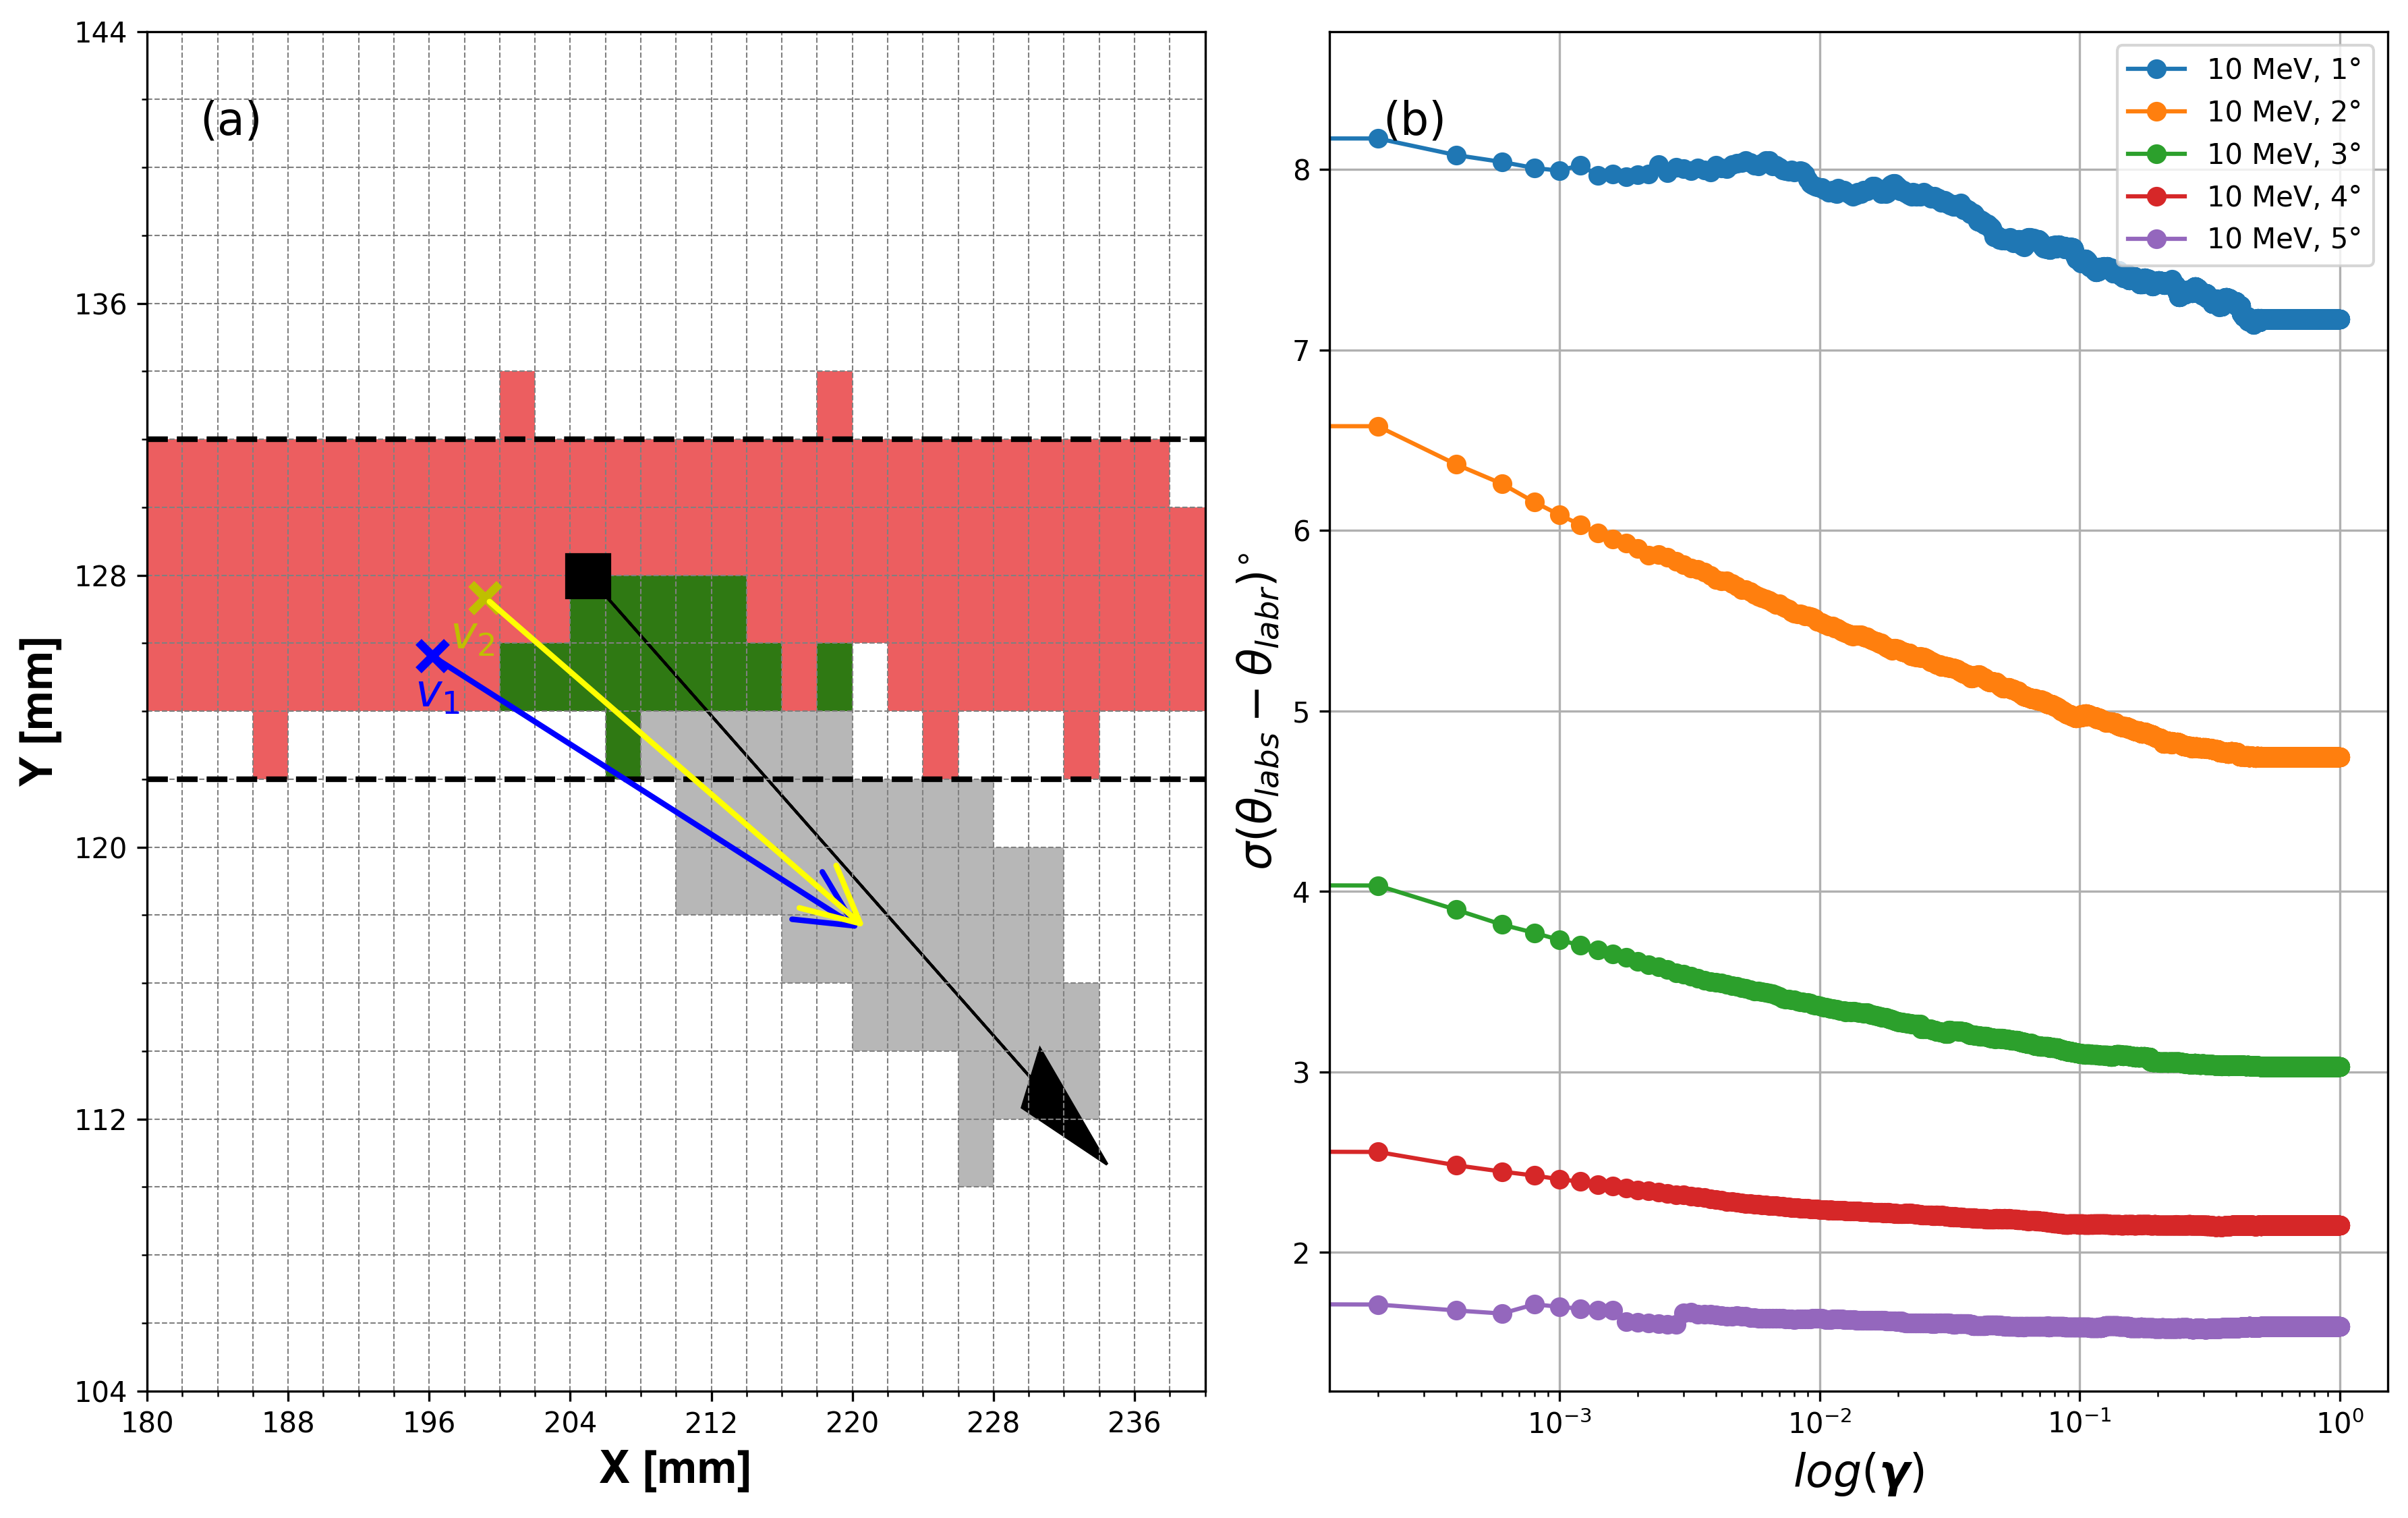

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

# Load the saved clusters from the specified iterations
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]

xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

# Set plot limits and grid size
x_limits = (180, 240)
y_limits = (104, 144)
pixel_size_mm = 2

# Create a 2x2 subplot for double-column format
fig, axs = plt.subplots(1, 2, figsize=(12, 8), dpi=300)

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}

# Function to add rectangle patches for each point
def add_rectangles(ax, xyz_data, labels, cmap):
    for (x, y, _), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm, linewidth=0.5,
                                 edgecolor='none', facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid and sparse Y-axis tick labels
def set_custom_grid(ax):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Set grid ticks every 2 mm on both axes
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=False)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, 8), minor=False)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, 8), minor=False)
    
    # Display grid
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

    # Label Y-axis major ticks every 8 mm
    y_labels = np.arange(y_limits[0], y_limits[1] + 1, 8)
    ax.set_yticklabels(y_labels)

    # Add thicker grid lines between Y = 122 and Y = 132
    ax.axhline(y=122, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=122
    ax.axhline(y=132, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=132


cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))
# Plot Initial Clusters
set_custom_grid(axs[0])
add_rectangles(axs[0], xyz_initial, labels_initial, cmap)
axs[0].set_xlabel('X [mm]', fontname='Arial', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Y [mm]', fontname='Arial', fontsize=16, fontweight='bold')

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]


# Add rectangles for mask_clusters in a different color (e.g., red)
for (x, y, _) in mask_clusters:
    rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                             linewidth=0.5, edgecolor='none', facecolor='green', alpha=0.8)
    axs[0].add_patch(rect)


mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, 0.16])

# Set a scaling factor to determine the length of the arrow (you can adjust this value)
scaling_factor = 29.56  # This controls how long the direction vector is on the plot

# Plot the mean point (starting point) and direction vector using ax.arrow
axs[0].arrow(mean_vector_1[0], mean_vector_1[1], direction_vector_1[0] * scaling_factor, direction_vector_1[1] * scaling_factor, 
          head_width=2, head_length=5, fc='k', ec='k')

axs[0].plot(mean_vector_1[0], mean_vector_1[1],
            marker='s', color='k', markersize=15,
            markeredgecolor='k', markeredgewidth=1.5,
            label='Mean Vector')


axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, fontsize=16, verticalalignment='top')


end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062]) 
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
# end_point_3 = np.array([180.69, 139.2822, 112.8984])
# start_point_3 = np.array([119.1046, 128.7794, 128.5239])

# axs[0].plot(end_point_1[0], end_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_1[0] + 1, end_point_1[1], '$e_1$', color='b', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_1[0], start_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_1[0] - 1, start_point_1[1] - 1.5, '$v_1$', color='b', fontsize=16, fontweight='bold') 

# axs[0].plot(end_point_2[0], end_point_2[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_2[0] + 1, end_point_2[1] - 2, '$e_2$', color='g', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_2[0], start_point_2[1], 'yx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_2[0]-2, start_point_2[1] - 1.5, '$v_2$', color='y', fontsize=16, fontweight='bold') 

# axs[0].plot(start_point_3[0], start_point_3[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(start_point_3[0]-2, start_point_3[1] - 1.5, '$v_2$', color='g', fontsize=16, fontweight='bold') 

# Scaling factor (how much to extend)
# scaling_factor = 1.0  # for example

# # Calculate directions
# dir1 = end_point_1 - start_point_1
# dir2 = end_point_2 - start_point_2

# # Extend points
# new_start_point_1 = start_point_1 
# new_end_point_1 = end_point_1 + scaling_factor * dir1

# new_start_point_2 = start_point_2 
# new_end_point_2 = end_point_2 + scaling_factor * dir2

# # Line 1 (XY projection)
# axs[0].plot(
#     [start_point_1[0], end_point_1[0]],
#     [start_point_1[1], end_point_1[1]],
#     color='blue',
#     linestyle='-',
#     linewidth=2,
#     label='Track 1 Extended'
# )

# # Line 2 (XY projection)
# axs[0].plot(
#     [start_point_2[0], end_point_2[0]],
#     [start_point_2[1], end_point_2[1]],
#     color='yellow',
#     linestyle='-',
#     linewidth=2,
#     label='Track 2 Extended'
# )

# Arrow 1 (Track 1 Extended)
axs[0].annotate(
    '', 
    xy=end_point_1[:2],
    xytext=start_point_1[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='blue',
        linewidth=2
    )
)

axs[0].annotate(
    '', 
    xy=end_point_2[:2],
    xytext=start_point_2[:2],
    arrowprops=dict(
        arrowstyle='->,head_length=2,head_width=1',
        color='yellow',
        linewidth=2
    )
)

# Load the array
data = np.load("angle_diff_resp.npy")

# Each row: [energy, cm, bin_low, bin_high, len_diffs, mean, sigma]
energies = data[:, 0]
cms = data[:, 1]
bin_lows = data[:, 2]
len_diffs = data[:, 4]
means = data[:, 5]
sigmas = data[:, 6]

# Find all unique (energy, cm) combinations
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

# Plot for each unique (energy, cm)
for energy, cm in unique_combinations:
    # Mask for current (energy, cm)
    mask = (data[:, 0] == energy) & (data[:, 1] == cm)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    sigma_vals = data[mask][:, 6]
    len_vals = data[mask][:, 4]

    label = f"{int(energy)} MeV, {int(cm)}°"
    
    # Plot Mean vs. bin_low
    axs[1].plot(bin_low_vals, sigma_vals, marker='o', label=label)
     
# Mean subplot
axs[1].set_xscale('log')
axs[1].set_xlabel(r'$log(\boldsymbol{\gamma})$', fontsize=16, fontweight='bold')
axs[1].set_ylabel(r'$\sigma(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
axs[1].text(0.05, 0.95, '(b)', transform=axs[1].transAxes, fontsize=16, verticalalignment='top')
# axs[1].set_xlim([0*100,0.1*100])
# axs[1].set_ylim([-2,7])
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('gamma.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_8776\2962865190.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))


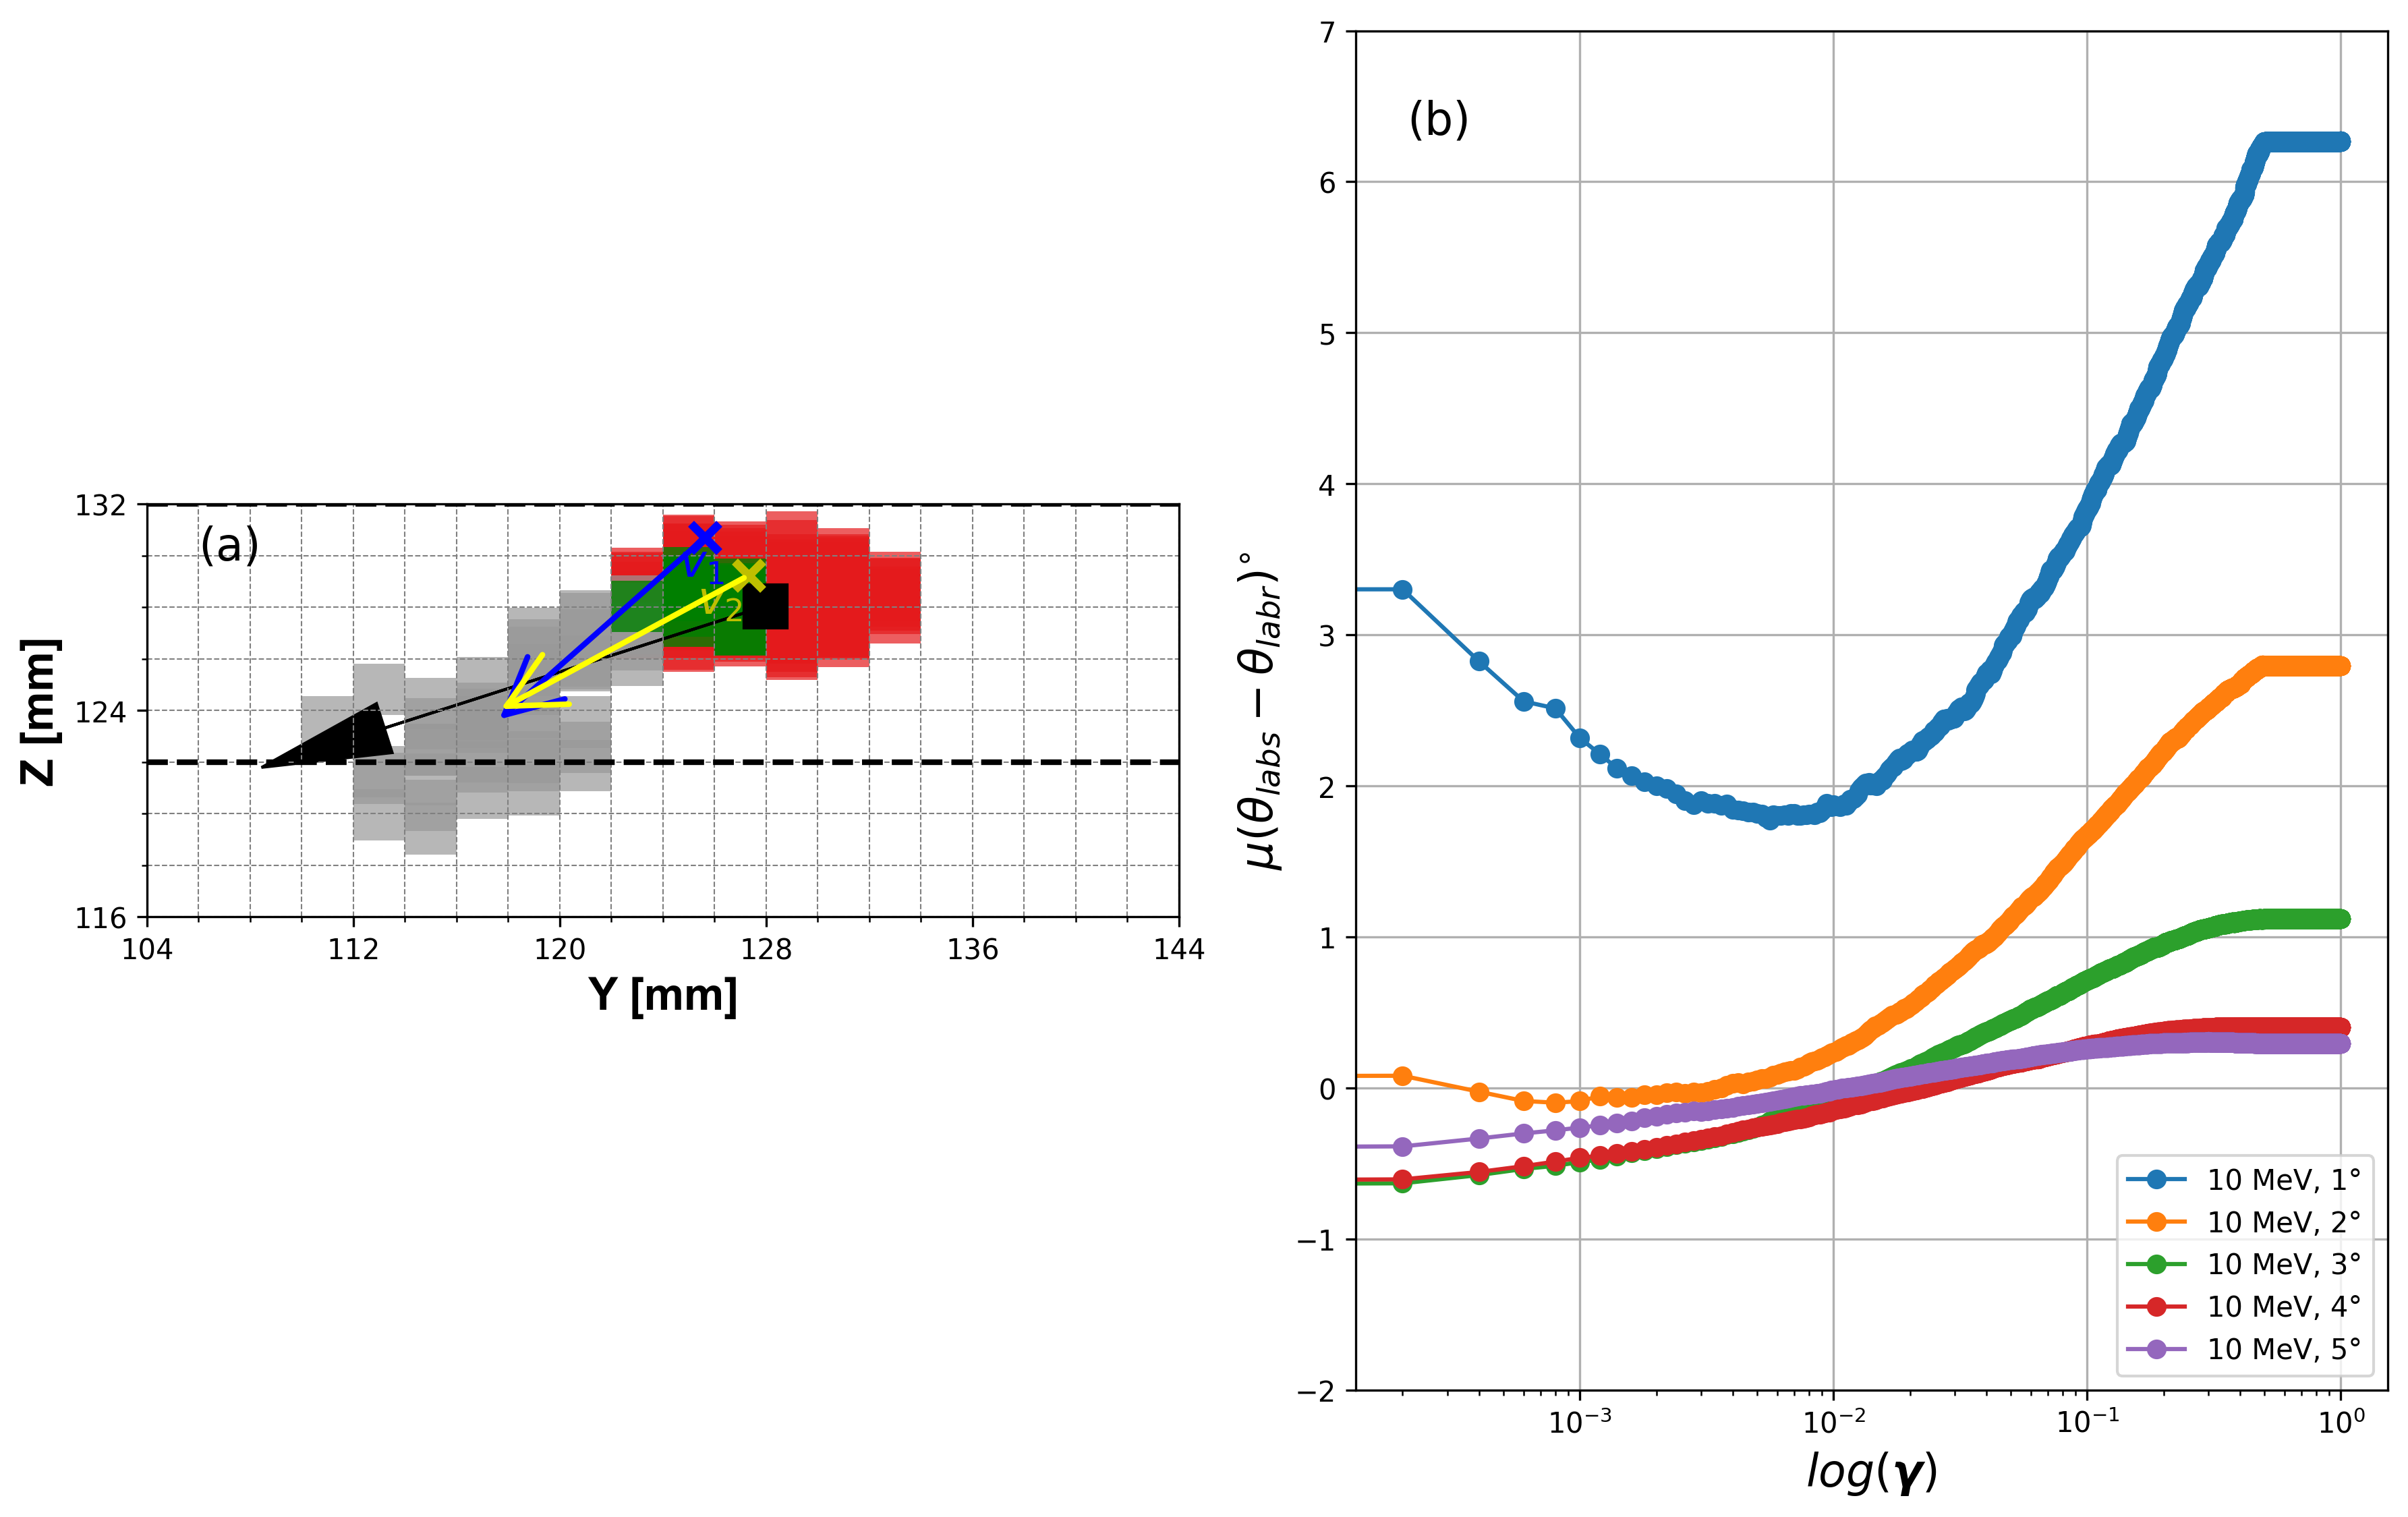

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

# Load the saved clusters from the specified iterations
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]

xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

# Set plot limits and grid size
x_limits = (104, 144)
y_limits = (116, 132)
pixel_size_mm = 2

# Create a 2x2 subplot for double-column format
fig, axs = plt.subplots(1, 2, figsize=(12, 8), dpi=300)

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}

# Function to add rectangle patches for each point
def add_rectangles(ax, xyz_data, labels, cmap):
    for (_, y, z), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        rect = patches.Rectangle((y, z), pixel_size_mm, pixel_size_mm,
                                 linewidth=0.5, edgecolor='none',
                                 facecolor=color, alpha=0.7)
        ax.add_patch(rect)

# Function to set custom grid and sparse Y-axis tick labels
def set_custom_grid(ax):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)

    ax.set_aspect('equal', adjustable='box')
    
    # Set grid ticks every 2 mm on both axes
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=False)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, pixel_size_mm), minor=True)
    ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 1, 8), minor=False)
    ax.set_xticks(np.arange(x_limits[0], x_limits[1] + 1, 8), minor=False)
    
    # Display grid
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

    # Label Y-axis major ticks every 8 mm
    y_labels = np.arange(y_limits[0], y_limits[1] + 1, 8)
    ax.set_yticklabels(y_labels)

    # Add thicker grid lines between Y = 122 and Y = 132
    ax.axhline(y=122, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=122
    ax.axhline(y=132, color='black', linewidth=2, linestyle='--')  # Thicker grid line at Y=132


cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))
# Plot Initial Clusters
set_custom_grid(axs[0])
add_rectangles(axs[0], xyz_initial, labels_initial, cmap)
axs[0].set_xlabel('Y [mm]', fontname='Arial', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Z [mm]', fontname='Arial', fontsize=16, fontweight='bold')

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]


for (_, y, z) in mask_clusters:
    rect = patches.Rectangle((y, z), pixel_size_mm, pixel_size_mm,
                             linewidth=0.5, edgecolor='none',
                             facecolor='green', alpha=0.8)
    axs[0].add_patch(rect)


mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, -0.16])

# Set a scaling factor to determine the length of the arrow (you can adjust this value)
scaling_factor = 29.56  # This controls how long the direction vector is on the plot

# Plot the mean point (starting point) and direction vector using ax.arrow
axs[0].arrow(mean_vector_1[1], mean_vector_1[2],
             direction_vector_1[1] * scaling_factor,
             direction_vector_1[2] * scaling_factor,
             head_width=2, head_length=5, fc='k', ec='k')

axs[0].plot(mean_vector_1[1], mean_vector_1[2],
            marker='s', color='k', markersize=15,
            markeredgecolor='k', markeredgewidth=1.5,
            label='Mean Vector')

axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, fontsize=16, verticalalignment='top')


end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062]) 
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
# end_point_3 = np.array([180.69, 139.2822, 112.8984])
# start_point_3 = np.array([119.1046, 128.7794, 128.5239])

# axs[0].plot(end_point_1[0], end_point_1[1], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_1[0] + 1, end_point_1[1], '$e_1$', color='b', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_1[1], start_point_1[2], 'bx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_1[1] - 1, start_point_1[2] - 1.5, '$v_1$', color='b', fontsize=16, fontweight='bold') 

# axs[0].plot(end_point_2[0], end_point_2[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(end_point_2[0] + 1, end_point_2[1] - 2, '$e_2$', color='g', fontsize=16, fontweight='bold') 

axs[0].plot(start_point_2[1], start_point_2[2], 'yx', label='Mean Vector', markersize=10, markeredgewidth=3)
axs[0].text(start_point_2[1]-2, start_point_2[2] - 1.5, '$v_2$', color='y', fontsize=16, fontweight='bold') 

# axs[0].plot(start_point_3[0], start_point_3[1], 'gx', label='Mean Vector', markersize=10, markeredgewidth=3)
# axs[0].text(start_point_3[0]-2, start_point_3[1] - 1.5, '$v_2$', color='g', fontsize=16, fontweight='bold') 

# Scaling factor (how much to extend)
# scaling_factor = 1.0  # for example

# # Calculate directions
# dir1 = end_point_1 - start_point_1
# dir2 = end_point_2 - start_point_2

# # Extend points
# new_start_point_1 = start_point_1 
# new_end_point_1 = end_point_1 + scaling_factor * dir1

# new_start_point_2 = start_point_2 
# new_end_point_2 = end_point_2 + scaling_factor * dir2

# # Line 1 (XY projection)
# axs[0].plot(
#     [start_point_1[0], end_point_1[0]],
#     [start_point_1[1], end_point_1[1]],
#     color='blue',
#     linestyle='-',
#     linewidth=2,
#     label='Track 1 Extended'
# )

# # Line 2 (XY projection)
# axs[0].plot(
#     [start_point_2[0], end_point_2[0]],
#     [start_point_2[1], end_point_2[1]],
#     color='yellow',
#     linestyle='-',
#     linewidth=2,
#     label='Track 2 Extended'
# )

# Arrow 1 (Track 1 Extended)
axs[0].annotate('', 
    xy=(end_point_1[1], end_point_1[2]),
    xytext=(start_point_1[1], start_point_1[2]),
    arrowprops=dict(arrowstyle='->,head_length=2,head_width=1',
                    color='blue', linewidth=2)
)

axs[0].annotate('', 
    xy=(end_point_2[1], end_point_2[2]),
    xytext=(start_point_2[1], start_point_2[2]),
    arrowprops=dict(arrowstyle='->,head_length=2,head_width=1',
                    color='yellow', linewidth=2)
)

# Load the array
data = np.load("angle_diff_resp.npy")

# Each row: [energy, cm, bin_low, bin_high, len_diffs, mean, sigma]
energies = data[:, 0]
cms = data[:, 1]
bin_lows = data[:, 2]
len_diffs = data[:, 4]
means = data[:, 5]
sigmas = data[:, 6]

# Find all unique (energy, cm) combinations
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

# Plot for each unique (energy, cm)
for energy, cm in unique_combinations:
    # Mask for current (energy, cm)
    mask = (data[:, 0] == energy) & (data[:, 1] == cm)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    sigma_vals = data[mask][:, 6]
    len_vals = data[mask][:, 4]

    label = f"{int(energy)} MeV, {int(cm)}°"
    
    # Plot Mean vs. bin_low
    axs[1].plot(bin_low_vals, mean_vals, marker='o', label=label)
     
# Mean subplot
axs[1].set_xscale('log')
axs[1].set_xlabel(r'$log(\boldsymbol{\gamma})$', fontsize=16, fontweight='bold')
axs[1].set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
axs[1].text(0.05, 0.95, '(b)', transform=axs[1].transAxes, fontsize=16, verticalalignment='top')
# axs[1].set_xlim([0*100,0.1*100])
axs[1].set_ylim([-2,7])
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('gamma.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_8776\2358155839.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))


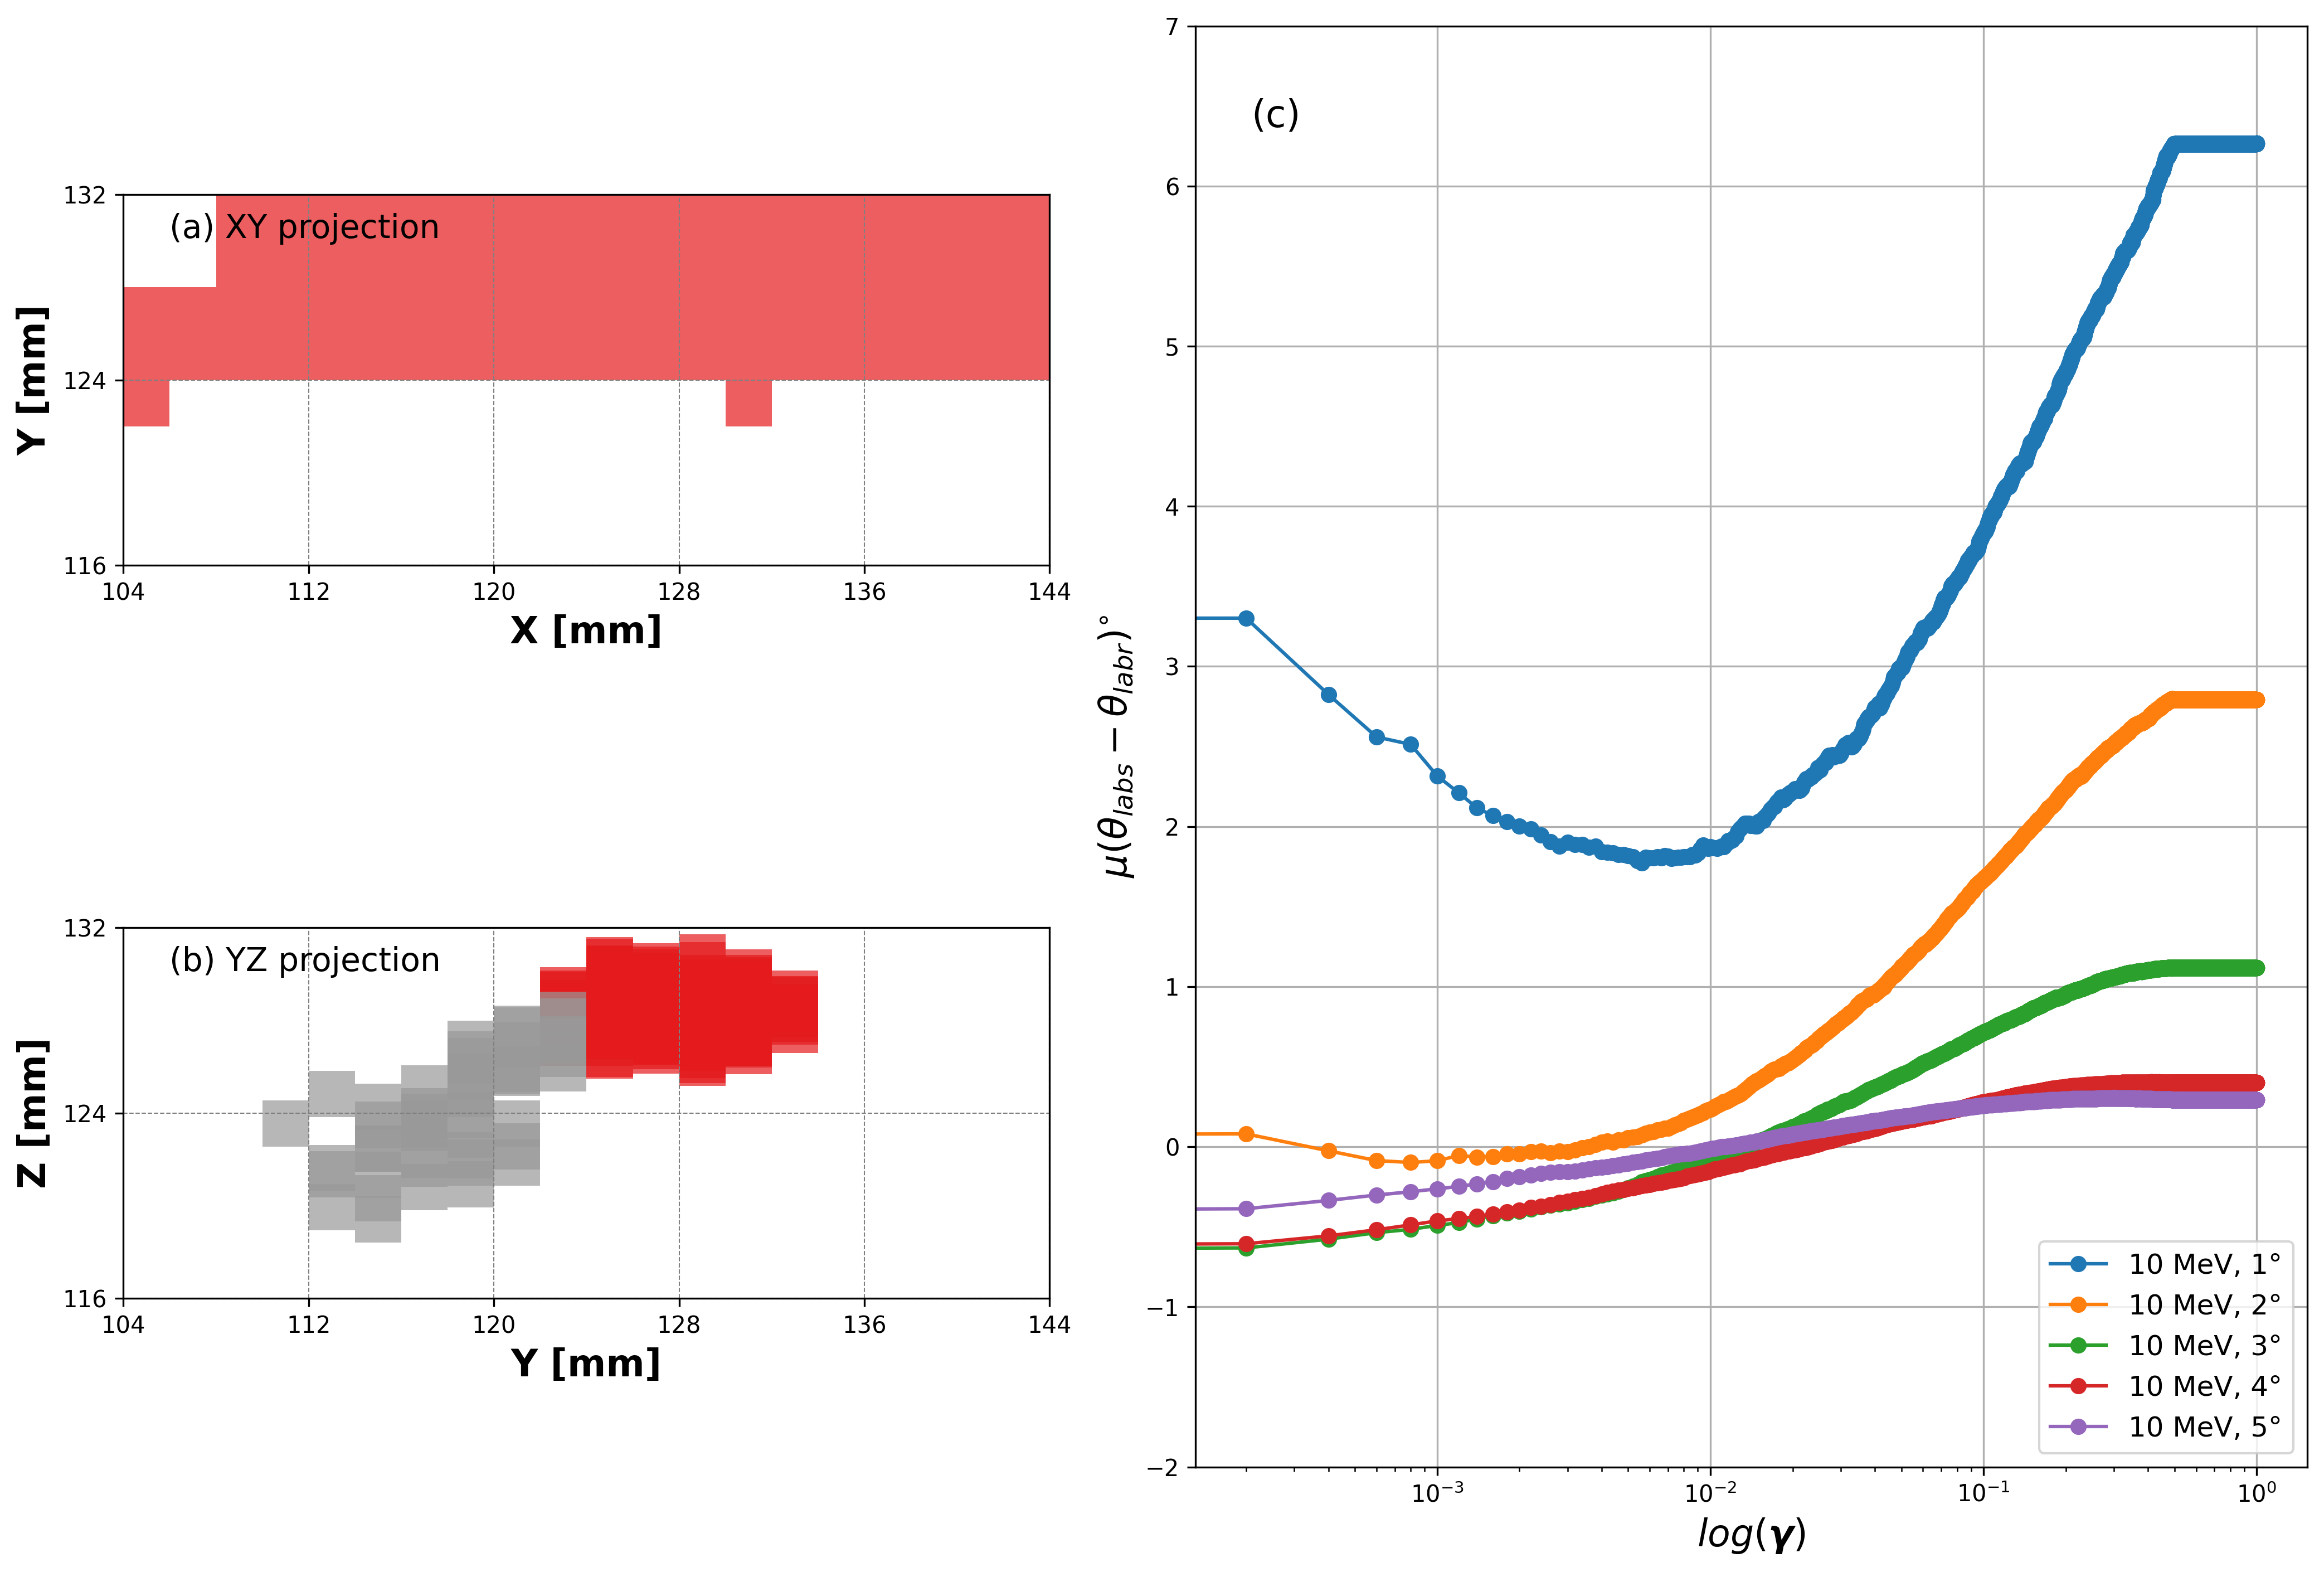

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

# Load data
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]
xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

x_limits = (104, 144)
y_limits = (116, 132)
pixel_size_mm = 2

# --- Create flexible 2x2 grid layout ---
fig = plt.figure(figsize=(14, 10), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2])  # left column narrower

ax_xy = fig.add_subplot(gs[0, 0])  # Top-left (XY projection)
ax_yz = fig.add_subplot(gs[1, 0])  # Bottom-left (YZ projection)
ax_mean = fig.add_subplot(gs[:, 1])  # Right column (mean plot spans both rows)

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}
cmap = plt.cm.get_cmap("Set1", len(np.unique(labels_initial)))

# --- Helper functions ---
def add_rectangles(ax, xyz_data, labels, cmap, projection='YZ'):
    for (x, y, z), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        if projection == 'YZ':
            rect = patches.Rectangle((y, z), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor=color, alpha=0.7)
        elif projection == 'XY':
            rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor=color, alpha=0.7)
        ax.add_patch(rect)

def set_custom_grid(ax, xlim, ylim):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 8))
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 8))
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

# --- Plot (a) XY projection ---
set_custom_grid(ax_xy, x_limits, y_limits)
add_rectangles(ax_xy, xyz_initial, labels_initial, cmap, projection='XY')
ax_xy.set_xlabel('X [mm]', fontsize=16, fontweight='bold')
ax_xy.set_ylabel('Y [mm]', fontsize=16, fontweight='bold')
ax_xy.text(0.05, 0.95, '(a) XY projection', transform=ax_xy.transAxes,
           fontsize=14, verticalalignment='top')

# --- Plot (b) YZ projection ---
set_custom_grid(ax_yz, x_limits, y_limits)
add_rectangles(ax_yz, xyz_initial, labels_initial, cmap, projection='YZ')
ax_yz.set_xlabel('Y [mm]', fontsize=16, fontweight='bold')
ax_yz.set_ylabel('Z [mm]', fontsize=16, fontweight='bold')
ax_yz.text(0.05, 0.95, '(b) YZ projection', transform=ax_yz.transAxes,
           fontsize=14, verticalalignment='top')

# --- Plot (c) Mean vs log(gamma) ---
data = np.load("angle_diff_resp.npy")
energies = data[:, 0]
cms = data[:, 1]
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

for energy, cm_val in unique_combinations:
    mask = (data[:, 0] == energy) & (data[:, 1] == cm_val)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    label = f"{int(energy)} MeV, {int(cm_val)}°"
    ax_mean.plot(bin_low_vals, mean_vals, marker='o', label=label)

ax_mean.set_xscale('log')
ax_mean.set_xlabel(r'$log(\boldsymbol{\gamma})$', fontsize=16, fontweight='bold')
ax_mean.set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
ax_mean.text(0.05, 0.95, '(c)', transform=ax_mean.transAxes, fontsize=16, verticalalignment='top')
ax_mean.set_ylim([-2, 7])
ax_mean.legend(fontsize=12)
ax_mean.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('gamma_combined.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_8776\2834205716.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(unique_labels))


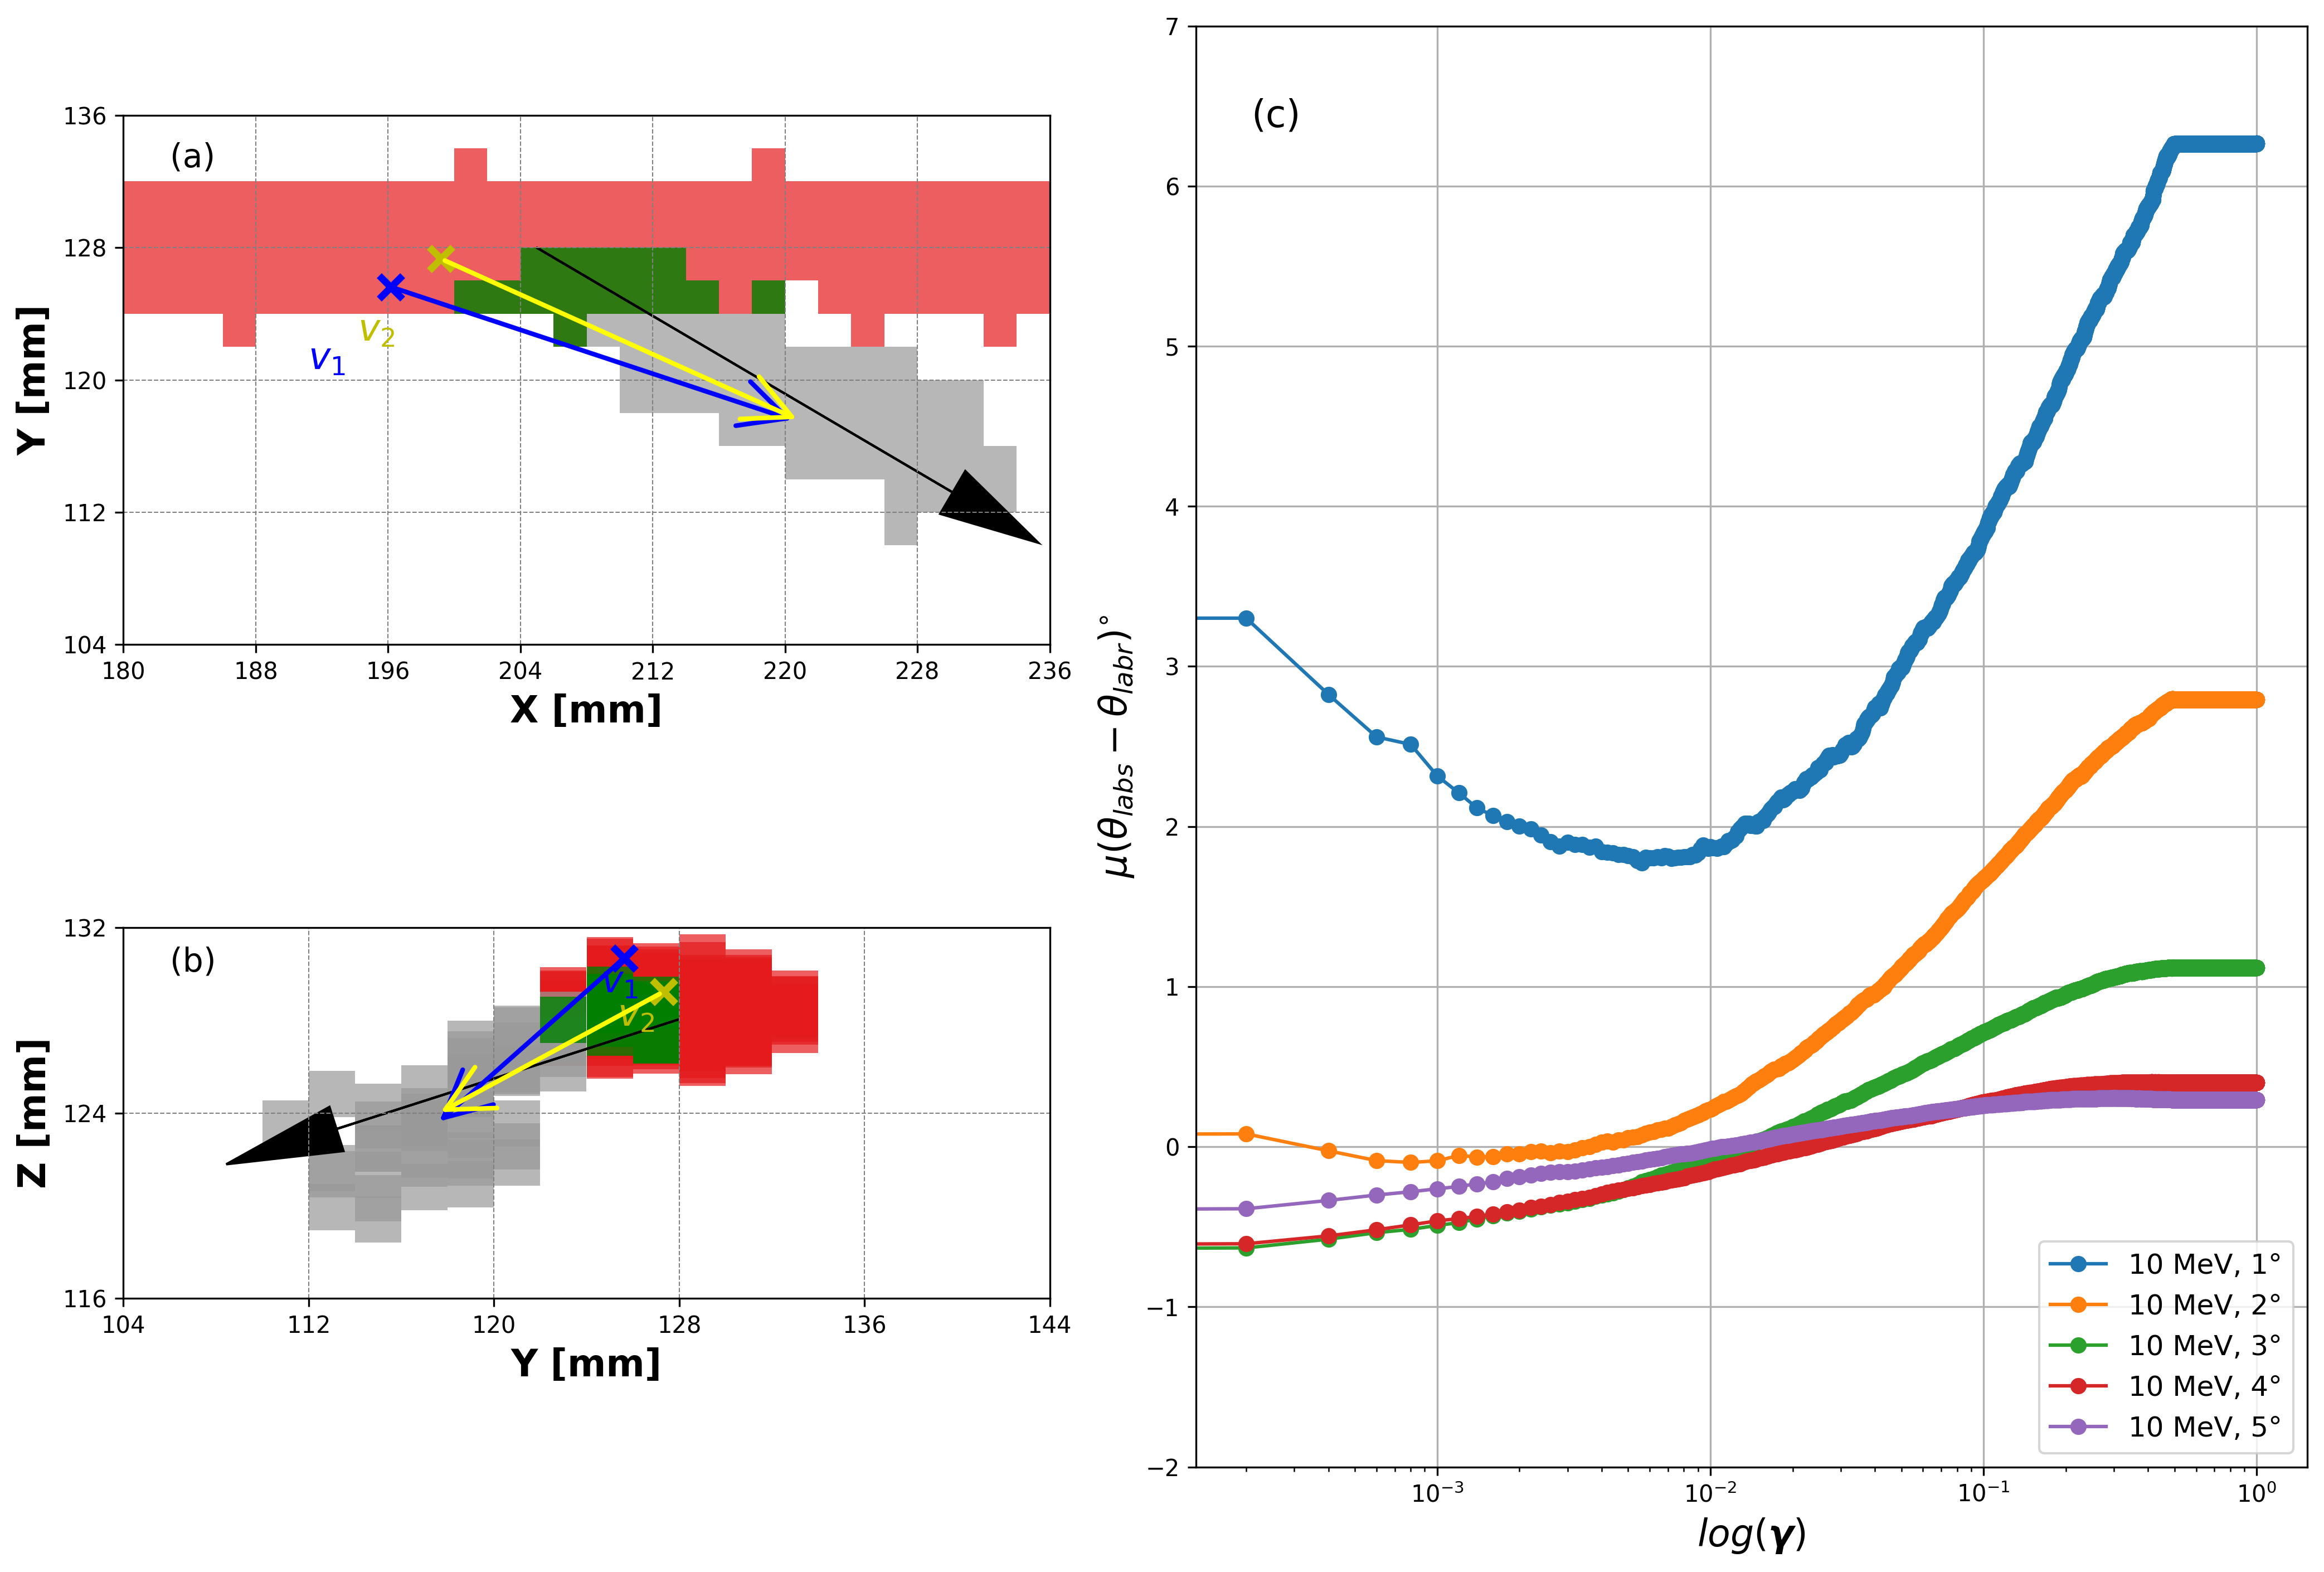

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

# ===============================
# Load data
# ===============================
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]
xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]

# --- Limits ---
x_limits_xy = (180, 236)
y_limits_xy = (104, 136)
x_limits_yz = (104, 144)
y_limits_yz = (116, 132)
pixel_size_mm = 2

# ===============================
# Figure layout (3 subplots)
# ===============================
fig = plt.figure(figsize=(14, 10), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2])

ax_xy = fig.add_subplot(gs[0, 0])   # (a) XY projection
ax_yz = fig.add_subplot(gs[1, 0])   # (b) YZ projection
ax_mean = fig.add_subplot(gs[:, 1]) # (c) consolidated graph

unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}
cmap = plt.cm.get_cmap("Set1", len(unique_labels))

# ===============================
# Helper functions
# ===============================
def add_rectangles(ax, xyz_data, labels, cmap, projection='YZ'):
    for (x, y, z), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        if projection == 'YZ':
            rect = patches.Rectangle((y, z), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor=color, alpha=0.7)
        elif projection == 'XY':
            rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor=color, alpha=0.7)
        ax.add_patch(rect)

def add_mask_rectangles(ax, mask_clusters, projection='YZ'):
    for (x, y, z) in mask_clusters:
        if projection == 'YZ':
            rect = patches.Rectangle((y, z), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor='green', alpha=0.8)
        elif projection == 'XY':
            rect = patches.Rectangle((x, y), pixel_size_mm, pixel_size_mm,
                                     linewidth=0.5, edgecolor='none',
                                     facecolor='green', alpha=0.8)
        ax.add_patch(rect)

def set_custom_grid(ax, xlim, ylim):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 8))
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 8))
    ax.grid(which="both", color="gray", linestyle="--", linewidth=0.5)

# ===============================
# Common vectors/arrows data
# ===============================
mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, -0.16])
scaling_factor = 29.56

start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062])
end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])

# ===============================
# (a) XY Projection
# ===============================
set_custom_grid(ax_xy, x_limits_xy, y_limits_xy)
add_rectangles(ax_xy, xyz_initial, labels_initial, cmap, projection='XY')
add_mask_rectangles(ax_xy, mask_clusters, projection='XY')

# Arrow for mean vector (projected on XY plane)
ax_xy.arrow(mean_vector_1[0],
            mean_vector_1[1],
            direction_vector_1[0] * scaling_factor,
            direction_vector_1[1] * scaling_factor,
            head_width=3, head_length=6, fc='k', ec='k')

# Start and end points (XY projection)
ax_xy.plot(start_point_1[0], start_point_1[1], 'bx', markersize=10, markeredgewidth=3)
ax_xy.text(start_point_1[0] - 5, start_point_1[1] - 5, '$v_1$', color='b', fontsize=16, fontweight='bold')

ax_xy.plot(start_point_2[0], start_point_2[1], 'yx', markersize=10, markeredgewidth=3)
ax_xy.text(start_point_2[0] - 5, start_point_2[1] - 5, '$v_2$', color='y', fontsize=16, fontweight='bold')

# Arrow annotations for tracks
ax_xy.annotate('', xy=(end_point_1[0], end_point_1[1]), xytext=(start_point_1[0], start_point_1[1]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='blue', linewidth=2))
ax_xy.annotate('', xy=(end_point_2[0], end_point_2[1]), xytext=(start_point_2[0], start_point_2[1]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='yellow', linewidth=2))

ax_xy.set_xlabel('X [mm]', fontsize=16, fontweight='bold')
ax_xy.set_ylabel('Y [mm]', fontsize=16, fontweight='bold')
ax_xy.text(0.05, 0.95, '(a)', transform=ax_xy.transAxes, fontsize=14, verticalalignment='top')

# ===============================
# (b) YZ Projection
# ===============================
set_custom_grid(ax_yz, x_limits_yz, y_limits_yz)
add_rectangles(ax_yz, xyz_initial, labels_initial, cmap, projection='YZ')
add_mask_rectangles(ax_yz, mask_clusters, projection='YZ')

# Arrow and vectors on YZ projection
ax_yz.arrow(mean_vector_1[1], mean_vector_1[2],
             direction_vector_1[1] * scaling_factor,
             direction_vector_1[2] * scaling_factor,
             head_width=2, head_length=5, fc='k', ec='k')

ax_yz.plot(start_point_1[1], start_point_1[2], 'bx', markersize=10, markeredgewidth=3)
ax_yz.text(start_point_1[1] - 1, start_point_1[2] - 1.5, '$v_1$', color='b', fontsize=16, fontweight='bold')

ax_yz.plot(start_point_2[1], start_point_2[2], 'yx', markersize=10, markeredgewidth=3)
ax_yz.text(start_point_2[1] - 2, start_point_2[2] - 1.5, '$v_2$', color='y', fontsize=16, fontweight='bold')

ax_yz.annotate('', xy=(end_point_1[1], end_point_1[2]), xytext=(start_point_1[1], start_point_1[2]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='blue', linewidth=2))
ax_yz.annotate('', xy=(end_point_2[1], end_point_2[2]), xytext=(start_point_2[1], start_point_2[2]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='yellow', linewidth=2))

ax_yz.set_xlabel('Y [mm]', fontsize=16, fontweight='bold')
ax_yz.set_ylabel('Z [mm]', fontsize=16, fontweight='bold')
ax_yz.text(0.05, 0.95, '(b)', transform=ax_yz.transAxes, fontsize=14, verticalalignment='top')

# ===============================
# (c) Consolidated Mean vs log(gamma)
# ===============================
data = np.load("angle_diff_resp.npy")
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

for energy, cm_val in unique_combinations:
    mask = (data[:, 0] == energy) & (data[:, 1] == cm_val)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    label = f"{int(energy)} MeV, {int(cm_val)}°"
    ax_mean.plot(bin_low_vals, mean_vals, marker='o', label=label)

ax_mean.set_xscale('log')
ax_mean.set_xlabel(r'$log(\boldsymbol{\gamma})$', fontsize=16, fontweight='bold')
ax_mean.set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=16, fontweight='bold')
ax_mean.text(0.05, 0.95, '(c)', transform=ax_mean.transAxes, fontsize=16, verticalalignment='top')
ax_mean.set_ylim([-2, 7])
ax_mean.legend(fontsize=12)
ax_mean.grid(True)

# ===============================
# Final layout
# ===============================
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


C:\Users\alarokia\AppData\Local\Temp\ipykernel_18940\3810204153.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(unique_labels))
C:\Users\alarokia\AppData\Local\Temp\ipykernel_18940\3810204153.py:231: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


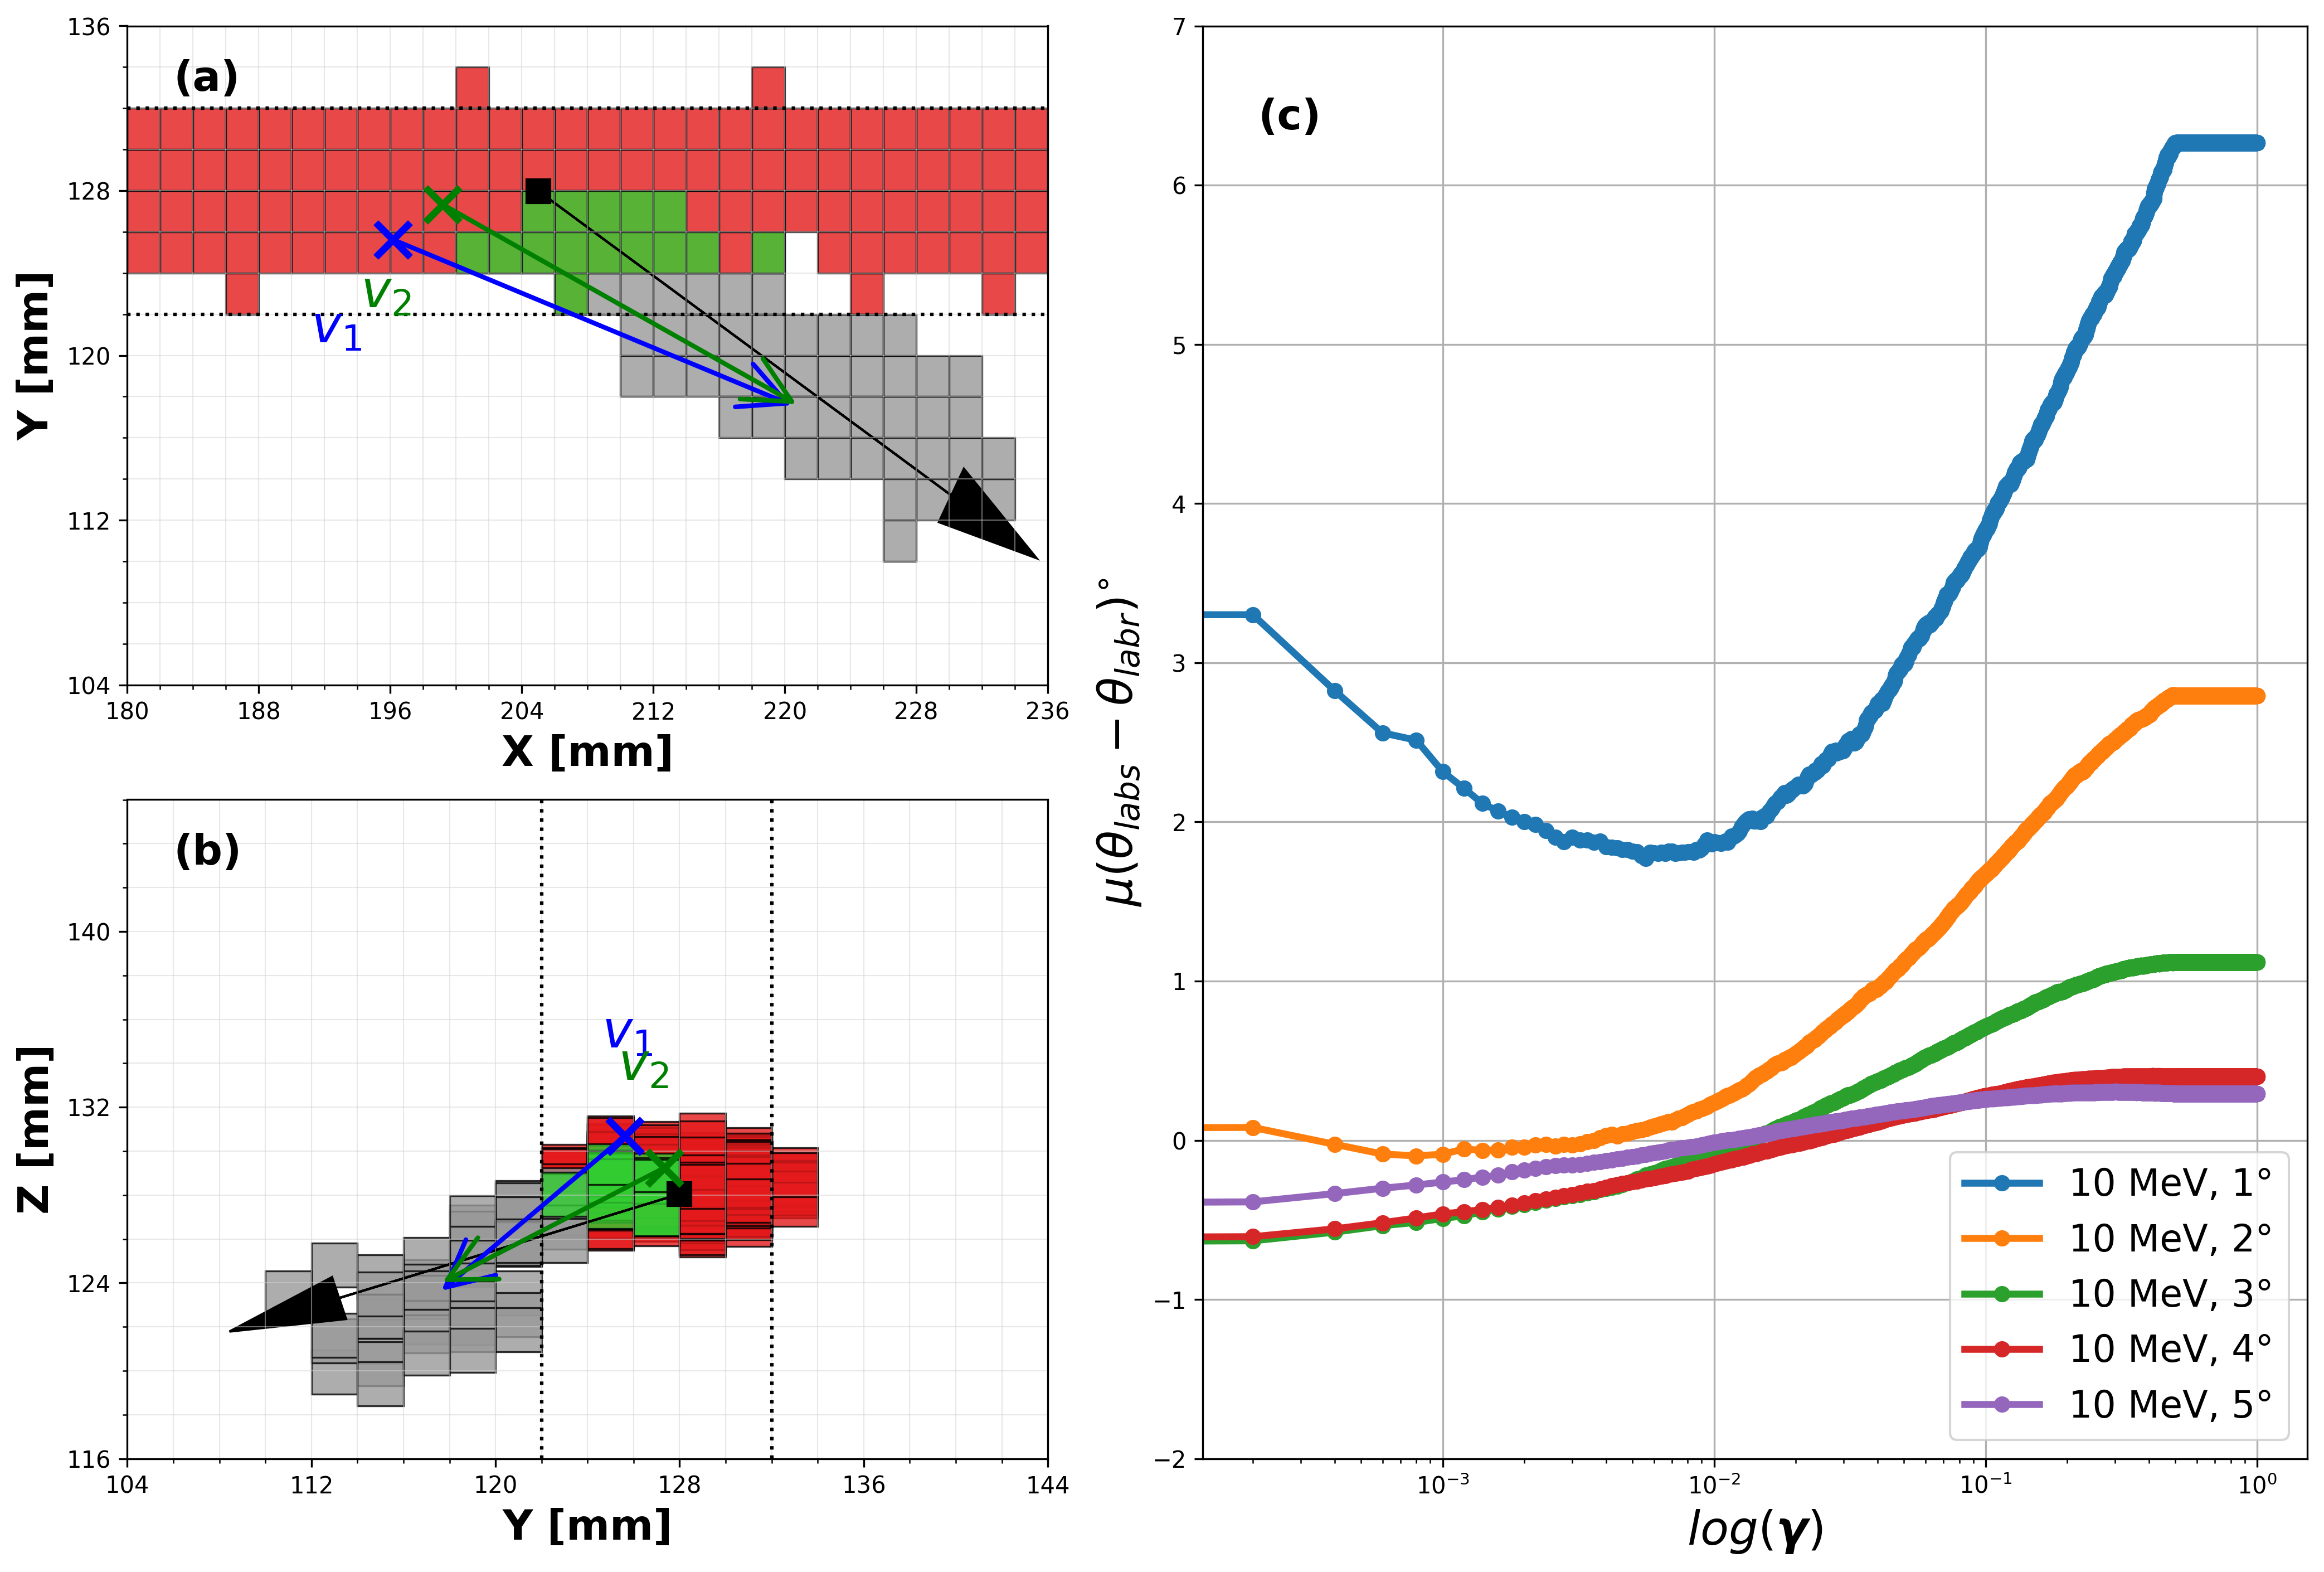

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

# ===============================
# Load data
# ===============================
initial_clusters = np.load('data_array_gamma.npy')
labels = initial_clusters[:, 11]
xyz_initial = initial_clusters[:, :3]
labels_initial = initial_clusters[:, 11]

mask_clusters_1 = np.load('data_array_gamma_mask.npy')
mask_clusters = mask_clusters_1[:, :3]

# --- Limits ---
x_limits_xy = (180, 236)
y_limits_xy = (104, 136)
x_limits_yz = (104, 144)
y_limits_yz = (116, 146)
pixel_size_mm = 2
axis_color = "green"  # goldenrod
# ===============================
# Figure layout (3 subplots)
# ===============================
fig = plt.figure(figsize=(14, 10), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])  # equal heights

ax_xy = fig.add_subplot(gs[0, 0])   # (a) XY projection
ax_yz = fig.add_subplot(gs[1, 0])   # (b) YZ projection
ax_mean = fig.add_subplot(gs[:, 1]) # (c) consolidated graph



unique_labels = np.unique(labels_initial)
label_to_color = {label: idx for idx, label in enumerate(unique_labels)}
cmap = plt.cm.get_cmap("Set1", len(unique_labels))

# ===============================
# Helper functions
# ===============================
def add_rectangles(ax, xyz_data, labels, cmap, projection='YZ'):
    """Plot voxel rectangles colored by cluster."""
    for (x, y, z), label in zip(xyz_data, labels):
        color = cmap(label_to_color[label])
        if projection == 'YZ':
            rect = patches.Rectangle(
                (y, z), pixel_size_mm, pixel_size_mm,
                linewidth=0.8, edgecolor='black',  # thicker border
                facecolor=color, alpha=0.8
            )
        elif projection == 'XY':
            rect = patches.Rectangle(
                (x, y), pixel_size_mm, pixel_size_mm,
                linewidth=0.8, edgecolor='black',
                facecolor=color, alpha=0.8
            )
        ax.add_patch(rect)

def add_mask_rectangles(ax, mask_clusters, projection='YZ'):
    """Plot green mask zone voxels."""
    for (x, y, z) in mask_clusters:
        if projection == 'YZ':
            rect = patches.Rectangle(
                (y, z), pixel_size_mm, pixel_size_mm,
                linewidth=0.8, edgecolor='black',
                facecolor='limegreen', alpha=0.8
            )
        elif projection == 'XY':
            rect = patches.Rectangle(
                (x, y), pixel_size_mm, pixel_size_mm,
                linewidth=0.8, edgecolor='black',
                facecolor='limegreen', alpha=0.8
            )
        ax.add_patch(rect)

# def set_custom_grid(ax, xlim, ylim):
#     """Set grid with 2 mm pixel spacing."""
#     ax.set_xlim(xlim)
#     ax.set_ylim(ylim)
#     ax.set_aspect('equal', adjustable='box')

#     # Set 2 mm grid spacing
#     ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, pixel_size_mm))
#     ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, pixel_size_mm))

#     # Major grid every 8 mm for readability
#     ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 8), minor=False)
#     ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 8), minor=False)

#     ax.grid(which="major", color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

def set_custom_grid(ax, xlim, ylim):
    """Set grid with 2 mm pixel spacing for display."""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('auto', adjustable='box')

    # Minor ticks every 2 mm (for grid lines)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, pixel_size_mm), minor=True)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, pixel_size_mm), minor=True)

    # Major ticks every 8 mm (for axis labels)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 8), minor=False)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 8), minor=False)

    # Draw grid lines for minor ticks (thin, light gray)
    ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
    # Draw grid lines for major ticks (thicker, darker gray)
    ax.grid(which='major', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
    # ax.set_aspect('equal', adjustable='box')
    
# ===============================
# Common vectors/arrows data
# ===============================
mean_vector_1 = np.array([205.01, 127.98, 128.04])
direction_vector_1 = np.array([0.85, -0.5, -0.16])
scaling_factor = 29.56

start_point_1 = np.array([196.17265353, 125.61990998, 130.69150062])
end_point_1 = np.array([220.69079822, 117.49551697, 123.5071119])
start_point_2 = np.array([199.18007279, 127.33059029, 129.23944021])
end_point_2 = np.array([220.9536227, 117.52218772, 123.94201652])

# ===============================
# (a) XY Projection
# ===============================
set_custom_grid(ax_xy, x_limits_xy, y_limits_xy)
add_rectangles(ax_xy, xyz_initial, labels_initial, cmap, projection='XY')
add_mask_rectangles(ax_xy, mask_clusters, projection='XY')

# Reaction vertex (black filled square)
ax_xy.plot(mean_vector_1[0], mean_vector_1[1],
            marker='s', color='k', markersize=10,
            markeredgecolor='black', label='Reaction Vertex')

# Arrow for mean vector (projected on XY plane)
ax_xy.arrow(mean_vector_1[0],
            mean_vector_1[1],
            direction_vector_1[0] * scaling_factor,
            direction_vector_1[1] * scaling_factor,
            head_width=3, head_length=6, fc='k', ec='k')

# Start points & arrows (XY)
ax_xy.plot(start_point_1[0], start_point_1[1], 'bx', markersize=15, markeredgewidth=3)
ax_xy.text(start_point_1[0] - 5, start_point_1[1] - 5, '$v_1$', color='b', fontsize=22, fontweight='bold')

ax_xy.plot(start_point_2[0], start_point_2[1], 'x', markersize=15, markeredgewidth=3, color=axis_color)
ax_xy.text(start_point_2[0] - 5, start_point_2[1] - 5, '$v_2$', color=axis_color, fontsize=22, fontweight='bold')

ax_xy.annotate('', xy=(end_point_1[0], end_point_1[1]), xytext=(start_point_1[0], start_point_1[1]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='blue', linewidth=2))
ax_xy.annotate('', xy=(end_point_2[0], end_point_2[1]), xytext=(start_point_2[0], start_point_2[1]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color=axis_color, linewidth=2))

ax_xy.axhline(y=122, color='black', linestyle=':', linewidth=1.5)
ax_xy.axhline(y=132, color='black', linestyle=':', linewidth=1.5)

ax_xy.set_xlabel('X [mm]', fontsize=18, fontweight='bold')
ax_xy.set_ylabel('Y [mm]', fontsize=18, fontweight='bold')
ax_xy.text(0.05, 0.95, '(a)', transform=ax_xy.transAxes, fontsize=18, fontweight = 'bold', verticalalignment='top')

# ===============================
# (b) YZ Projection
# ===============================
set_custom_grid(ax_yz, x_limits_yz, y_limits_yz)
add_rectangles(ax_yz, xyz_initial, labels_initial, cmap, projection='YZ')
add_mask_rectangles(ax_yz, mask_clusters, projection='YZ')

# Reaction vertex (black square)
ax_yz.plot(mean_vector_1[1], mean_vector_1[2],
           marker='s', color='k', markersize=10,
           markeredgecolor='black', label='Reaction Vertex')

# Arrow and vectors
ax_yz.arrow(mean_vector_1[1], mean_vector_1[2],
             direction_vector_1[1] * scaling_factor,
             direction_vector_1[2] * scaling_factor,
             head_width=2, head_length=5, fc='k', ec='k')

ax_yz.plot(start_point_1[1], start_point_1[2], 'bx', markersize=15, markeredgewidth=3)
ax_yz.text(start_point_1[1] - 1, start_point_1[2] + 4, '$v_1$', color='b', fontsize=22, fontweight='bold')

ax_yz.plot(start_point_2[1], start_point_2[2], 'x', markersize=15, markeredgewidth=3, color=axis_color)
ax_yz.text(start_point_2[1] - 2, start_point_2[2] + 4, '$v_2$', color=axis_color, fontsize=22, fontweight='bold')

ax_yz.annotate('', xy=(end_point_1[1], end_point_1[2]), xytext=(start_point_1[1], start_point_1[2]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color='blue', linewidth=2))
ax_yz.annotate('', xy=(end_point_2[1], end_point_2[2]), xytext=(start_point_2[1], start_point_2[2]),
               arrowprops=dict(arrowstyle='->,head_length=2,head_width=1', color=axis_color, linewidth=2))

ax_yz.axvline(x=122, color='black', linestyle=':', linewidth=1.5)
ax_yz.axvline(x=132, color='black', linestyle=':', linewidth=1.5)

ax_yz.set_xlabel('Y [mm]', fontsize=18, fontweight='bold')
ax_yz.set_ylabel('Z [mm]', fontsize=18, fontweight='bold')
ax_yz.text(0.05, 0.95, '(b)', transform=ax_yz.transAxes, fontsize=18, fontweight = 'bold', verticalalignment='top')

# ===============================
# (c) Consolidated Mean vs log(gamma)
# ===============================
data = np.load("angle_diff_resp.npy")
unique_combinations = np.unique(data[:, [0, 1]], axis=0)

for energy, cm_val in unique_combinations:
    mask = (data[:, 0] == energy) & (data[:, 1] == cm_val)
    bin_low_vals = data[mask][:, 2]
    mean_vals = data[mask][:, 5]
    label = f"{int(energy)} MeV, {int(cm_val)}°"
    ax_mean.plot(bin_low_vals, mean_vals, marker='o', label=label, linewidth=3)

ax_mean.set_xscale('log')
ax_mean.set_xlabel(r'$log(\boldsymbol{\gamma})$', fontsize=20, fontweight='bold')
ax_mean.set_ylabel(r'$\mu(\theta_{labs} - \theta_{labr})^{\circ}$', fontsize=20, fontweight='bold')
ax_mean.text(0.05, 0.95, '(c)', transform=ax_mean.transAxes, fontsize=18, verticalalignment='top', fontweight='bold')
ax_mean.set_ylim([-2, 7])
ax_mean.legend(fontsize=16)
ax_mean.grid(True)

# Reduce vertical height of C to align with XY top
# pos = ax_c.get_position()        # Bbox: [x0, y0, width, height]
# new_pos = [pos.x0, pos.y0 + 0.05, pos.width, pos.height - 10]  # move bottom up slightly, shrink height
# ax_c.set_position(new_pos)


# ===============================
# Final layout
# ===============================
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig('gamma_figure.png', format='png', dpi=300, bbox_inches='tight')
